# Análise Exploratória — TCC_SIM
**Tema:** Transição Epidemiológica e Padrões de Mortalidade no Estado de São Paulo (2000–2024)  
**Fonte:** Microdados SIM/DATASUS processados em `analise_inicial.ipynb`  
**Parquet:** `variavel/dataframe_tratado.parquet` (41 colunas, ~7,45M linhas)

> **Atenção:** este notebook carrega apenas o parquet final — não reexecuta o ETL.

---
## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import sidrapy

PARQUET = Path('variavel/dataframe_tratado.parquet')
FIGURAS = Path('variavel/figuras')
FIGURAS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

print('Setup OK')

Setup OK


In [3]:
# Classificação de grupos de causa baseada no código CID-10 (opera sobre CAUSABAS)
# Não depende do join com cid10.csv — resolve os 26.974 registros sem DESCR
def grupo_cid(codigo):
    if pd.isna(codigo):
        return 'Ignorado'
    c = str(codigo).strip().upper()
    if not c:
        return 'Ignorado'
    ch = c[0]
    if ch in ('A', 'B'):                          return 'Infecciosas e Parasitárias'
    if ch == 'C' or (ch == 'D' and c[1:3] in
       ['00','01','02','03','04','05','06','07',
        '08','09','10','11','12','13','14','15',
        '16','17','18','19','20','21','22','23',
        '24','25','26','27','28','29','30','31',
        '32','33','34','35','36','37','38','39',
        '40','41','42','43','44','45','46','47','48']):  return 'Neoplasias'
    if ch == 'D':                                 return 'Doenças do Sangue'
    if ch == 'E':                                 return 'Endócrinas e Metabólicas'
    if ch == 'F':                                 return 'Transtornos Mentais'
    if ch == 'G':                                 return 'Sistema Nervoso'
    if ch == 'I':                                 return 'Cardiovasculares'
    if ch == 'J':                                 return 'Respiratórias'
    if ch == 'K':                                 return 'Digestivas'
    if ch == 'L':                                 return 'Pele'
    if ch == 'M':                                 return 'Musculoesqueléticas'
    if ch == 'N':                                 return 'Genitourinárias'
    if ch in ('O', 'P'):                          return 'Maternas e Perinatais'
    if ch == 'Q':                                 return 'Malformações Congênitas'
    if ch == 'R':                                 return 'Causas Mal Definidas'
    if ch in ('V', 'W', 'X', 'Y'):               return 'Causas Externas'
    return 'Outras'

RACACOR_MAP = {
    '1': 'Branca', '2': 'Preta', '3': 'Amarela', '4': 'Parda', '5': 'Indígena',
     1:  'Branca',  2:  'Preta',  3:  'Amarela',  4:  'Parda',  5:  'Indígena',
}

SEXO_MAP = {'1': 'Masculino', '2': 'Feminino', 1: 'Masculino', 2: 'Feminino'}

print('Funções auxiliares definidas')

Funções auxiliares definidas


In [4]:
# Carrega apenas as colunas necessárias para economizar memória
COLUNAS = [
    'DTOBITO', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR',
    'ESC', 'ESC2010', 'CAUSABAS', 'DESCR', 'CAT', 'SUBCAT',
    'CODMUNRES', 'MUNNOMEX', 'CAPITAL', 'UF', 'LOCOCOR',
]

df = pd.read_parquet(PARQUET, columns=COLUNAS)

# Garante datetime
for col in ('DTOBITO', 'DTNASC'):
    if df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], errors='coerce', format='%d%m%Y')
    else:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df['ANO']       = df['DTOBITO'].dt.year
df['MES']       = df['DTOBITO'].dt.month
df['ANO_MES']   = df['DTOBITO'].dt.to_period('M')
df['GRUPO_CAUSA'] = df['CAUSABAS'].apply(grupo_cid)
df['RACACOR_NOME'] = df['RACACOR'].map(RACACOR_MAP)
df['SEXO_NOME']    = df['SEXO'].map(SEXO_MAP)

# Período de análise: excluir 2025 das tendências (dado incompleto)
df_full  = df.copy()                        # 2000–2025 (para excess mortality)
df       = df[df['ANO'] <= 2024].copy()     # 2000–2024 (tendências)

print(f'Registros 2000–2024: {len(df):,}')
print(f'Colunas: {df.columns.tolist()}')
df.head(3)

Registros 2000–2024: 7,096,290
Colunas: ['DTOBITO', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESC', 'ESC2010', 'CAUSABAS', 'DESCR', 'CAT', 'SUBCAT', 'CODMUNRES', 'MUNNOMEX', 'CAPITAL', 'UF', 'LOCOCOR', 'ANO', 'MES', 'ANO_MES', 'GRUPO_CAUSA', 'RACACOR_NOME', 'SEXO_NOME']


,DTOBITO,DTNASC,IDADE,SEXO,RACACOR,ESC,ESC2010,CAUSABAS,DESCR,CAT,...,MUNNOMEX,CAPITAL,UF,LOCOCOR,ANO,MES,ANO_MES,GRUPO_CAUSA,RACACOR_NOME,SEXO_NOME
354163,2000-07-13,1947-04-28,53.21,1,None,None,None,E148,E14.8 C/compl NE,N,...,SAO PAULO,S,SP,1,2000,7,2000-07,Endócrinas e Metabólicas,NaN,Masculino
354164,2000-07-20,1954-08-21,45.91,1,None,None,None,D849,D84.9 Imunodeficiencia NE,N,...,GUARULHOS,N,SP,1,2000,7,2000-07,Doenças do Sangue,NaN,Masculino
354165,2000-07-03,1995-11-09,4.65,1,4,2,None,V099,V09.9 Acid transp NE,N,...,SANTA ISABEL,N,SP,1,2000,7,2000-07,Causas Externas,Parda,Masculino


In [5]:
df_full.sample(5).transpose()

,5675318,1913531,1827519,3018897,6807100
DTOBITO,2005-02-27 00:00:00,2012-04-02 00:00:00,2008-12-24 00:00:00,2001-02-20 00:00:00,2016-04-18 00:00:00
DTNASC,1940-03-29 00:00:00,1990-07-02 00:00:00,1923-04-09 00:00:00,1918-12-10 00:00:00,1930-06-03 00:00:00
IDADE,64.92,21.75,85.71,82.2,85.88
SEXO,1,1,2,1,1
RACACOR,1,1,1,1,1
ESC,2,3,None,None,None
ESC2010,None,2,None,None,None
CAUSABAS,C187,X954,C259,J440,J984
DESCR,C18.7 Colon sigmoide,X95.4 Rua e estrada,C25.9 Pancreas NE,J44.0 Doen pulm obs cron c/inf resp ag tr resp...,J98.4 Outr transt pulmonares
CAT,N,N,N,N,N


In [6]:
print("Coletando dados com a biblioteca oficial do IBGE (SIDRA)...")

try:
    # Coleta os dados da Tabela 6579 (Estimativas de População)
    # table_code='6579' -> Tabela de estimativas
    # variable='9324'   -> População residente estimada
    # period='all'       -> Todos os anos da série
    # territorial_level='6' -> Nível de Municípios
    # ibge_territorial_code='35' -> Estado de São Paulo (Código 35)
    
    df_raw = sidrapy.get_table(
        table_code="6579",
        variable="9324",
        period="all",
        territorial_level="3",
        ibge_territorial_code="35",
        contido="35",  # Filtra para trazer apenas os municípios contidos em SP (Código 35)
    )

    # O IBGE retorna a primeira linha como cabeçalho de descrição, vamos removê-la
    df_limpo = df_raw.iloc[1:].copy()

    # Renomear as colunas para o nosso idioma de análise
    df_final = df_limpo[
        [
            "D1C",
            "D1N",
            "D2C",
            "D3C",
            "V",
        ]
    ].rename(
        columns={
            "D1C": "Código Município",
            "D1N": "Município",
            "D2C": "Ano",
            "D3C": "Variável",
            "V": "População",
        }
    )

    # Converter População e Ano para valores numéricos
    df_final["Ano"] = pd.to_numeric(df_final["Ano"])
    df_final["População"] = pd.to_numeric(df_final["População"], errors="coerce")

    # Ordenar por cidade e ano
    df_final = df_final.sort_values(by=["Município", "Ano"])

    # Salvar em Excel
    nome_arquivo = "populacao_sp_sidrapy.xlsx"
    df_final.to_excel(nome_arquivo, index=False)

    print(
        f"\nSucesso total! Arquivo '{nome_arquivo}' gerado com {len(df_final)} registros."
    )
    print("Amostra dos dados salvos:")
    print(df_final.head())

except Exception as e:
    print(f"\nOcorreu uma falha ao processar os dados: {e}")


Coletando dados com a biblioteca oficial do IBGE (SIDRA)...

Sucesso total! Arquivo 'populacao_sp_sidrapy.xlsx' gerado com 22 registros.
Amostra dos dados salvos:
  Código Município  Município   Ano Variável  População
1               35  São Paulo  2001     9324   37630106
2               35  São Paulo  2002     9324   38177742
3               35  São Paulo  2003     9324   38709320
4               35  São Paulo  2004     9324   39825226
5               35  São Paulo  2005     9324   40442795


---
## 1. Cobertura Temporal
Verificar consistência do volume anual e identificar anomalias.

In [10]:
obitos_ano = df_full.groupby('ANO').size().reset_index(name='obitos')
obitos_ano['var_pct'] = obitos_ano['obitos'].pct_change() * 100

print(obitos_ano.to_string(index=False))
print(f"\nTotal 2000–2024: {obitos_ano[obitos_ano.ANO <= 2024]['obitos'].sum():,.0f}")
print(f"2025 (incompleto): {obitos_ano[obitos_ano.ANO == 2025]['obitos'].values[0]:,.0f}")

 ANO  obitos    var_pct
2000  238848        NaN
2001  235948  -1.214161
2002  237717   0.749741
2003  240224   1.054615
2004  243964   1.556880
2005  236438  -3.084881
2006  243950   3.177154
2007  244645   0.284894
2008  249237   1.877005
2009  256621   2.962642
2010  264940   3.241746
2011  270358   2.044991
2012  270421   0.023302
2013  276971   2.422149
2014  281609   1.674544
2015  287639   2.141267
2016  296353   3.029492
2017  294746  -0.542259
2018  298301   1.206123
2019  306183   2.642298
2020  349629  14.189553
2021  431603  23.445996
2022  354046 -17.969523
2023  334296  -5.578371
2024  351603   5.177148
2025  354163   0.728094

Total 2000–2024: 7,096,290
2025 (incompleto): 354,163


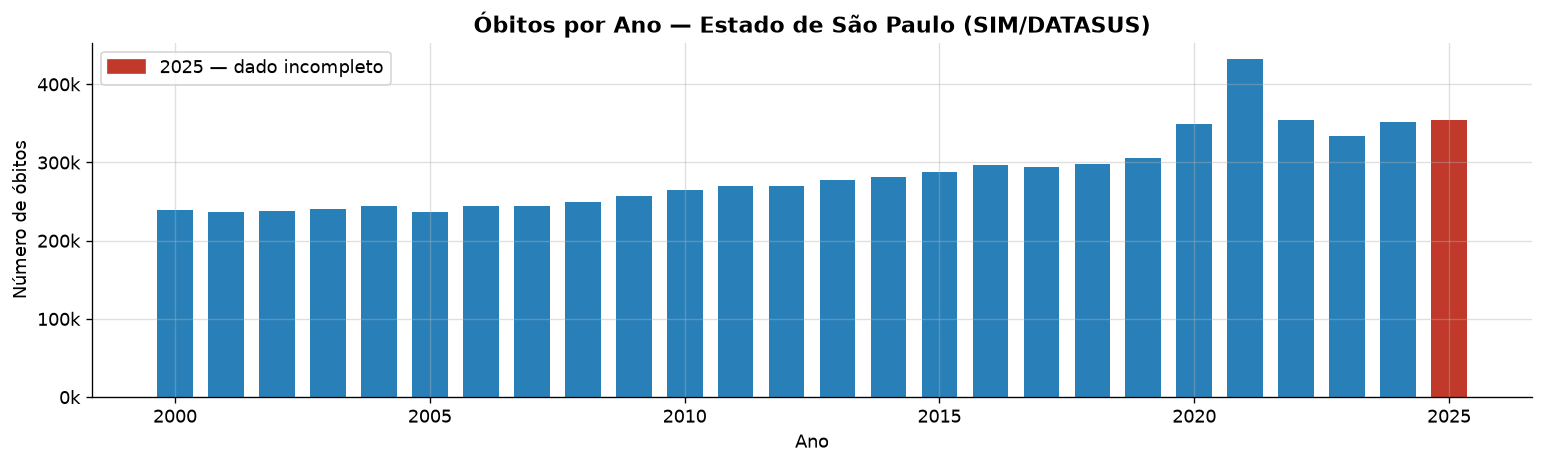

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))

anos_full = obitos_ano['ANO']
obs_full  = obitos_ano['obitos']

# barra cinza para 2025 (incompleto)
cores = ['#c0392b' if a == 2025 else '#2980b9' for a in anos_full]
ax.bar(anos_full, obs_full, color=cores, width=0.7)

ax.set_title('Óbitos por Ano — Estado de São Paulo (SIM/DATASUS)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de óbitos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}k'))

patch_inc = mpatches.Patch(color='#c0392b', label='2025 — dado incompleto')
ax.legend(handles=[patch_inc], loc='upper left')

plt.tight_layout()
fig.savefig(FIGURAS / 'fig01_obitos_por_ano.png', bbox_inches='tight')
plt.show()

---
## 2. Série Temporal Normalizada (taxa por 100 mil habitantes)

> **Fonte:** `tabelas_depara/estimativa_populacional_sp_municipios.xlsx`  
> Tabela 6579 IBGE/SIDRA — população residente estimada por estado, série 2001–2026.  
> Anos faltantes (2000, 2007, 2010, 2022, 2023) são interpolados linearmente.

Anos disponiveis no Excel (ate 2024): [2001, 2002, 2003, 2004, 2005, 2006, 2008, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2024]
Anos interpolados/extrapolados: [2000, 2007, 2010, 2022, 2023]



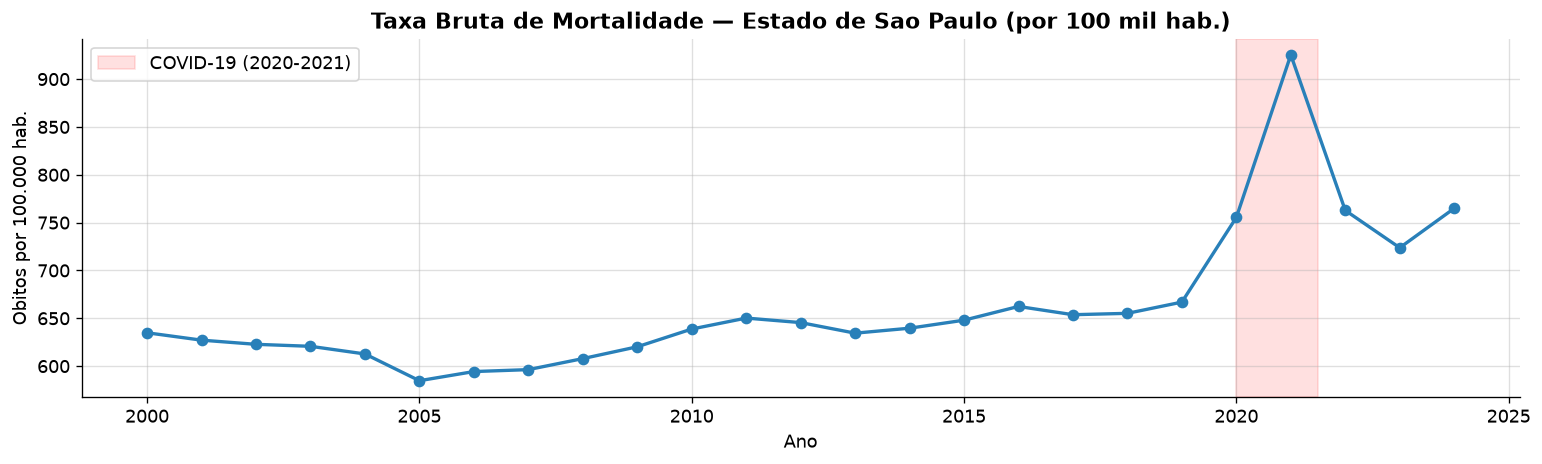

 ANO  obitos    populacao  taxa_100k
2000  238848 3.763011e+07 634.725823
2001  235948 3.763011e+07 627.019228
2002  237717 3.817774e+07 622.658616
2003  240224 3.870932e+07 620.584397
2004  243964 3.982523e+07 612.586605
2005  236438 4.044280e+07 584.623293
2006  243950 4.105573e+07 594.192275
2007  244645 4.103369e+07 596.205274
2008  249237 4.101164e+07 607.722618
2009  256621 4.138404e+07 620.096555
2010  264940 4.148561e+07 638.631074
2011  270358 4.158718e+07 650.099350
2012  270421 4.190122e+07 645.377405
2013  276971 4.366367e+07 634.328279
2014  281609 4.403530e+07 639.507337
2015  287639 4.439648e+07 647.886891
2016  296353 4.474970e+07 662.245795
2017  294746 4.509487e+07 653.613207
2018  298301 4.553894e+07 655.046047
2019  306183 4.591905e+07 666.788635
2020  349629 4.628933e+07 755.312244
2021  431603 4.664913e+07 925.211213
2022  354046 4.642382e+07 762.638674
2023  334296 4.619851e+07 723.607805
2024  351603 4.597319e+07 764.800027


In [13]:
# Carrega estimativas populacionais do Excel IBGE/SIDRA (Tabela 6579)
# Estrutura: row 3 (0-based) = cabecalho com anos; codigo '35' = Estado SP
POP_FILE = 'tabelas_depara/estimativa_populacional_sp_municipios.xlsx'

df_pop_raw = pd.read_excel(POP_FILE, sheet_name='Tabela', header=3)

# Normaliza nomes das colunas: 2002.0 -> '2002'
novos_cols = []
for c in df_pop_raw.columns:
    cs = str(c).strip()
    if cs.endswith('.0'):
        cs = cs[:-2]
    novos_cols.append(cs)
df_pop_raw.columns = novos_cols

# Linha do Estado de Sao Paulo — primeira coluna contem o codigo '35'
col_cod = df_pop_raw.columns[0]
sp_row = df_pop_raw[df_pop_raw[col_cod].astype(str).str.strip() == '35'].iloc[0]

# Colunas que representam anos
cols_anos = [c for c in df_pop_raw.columns if c.isdigit() and len(c) == 4]

# Monta serie longa: ano -> populacao
pop = pd.DataFrame({
    'ano': [int(c) for c in cols_anos],
    'populacao': [pd.to_numeric(sp_row[c], errors='coerce') for c in cols_anos]
})
pop = pop[pop['populacao'].notna()].copy()

# Expande para 2000-2024; interpola internamente, extrapola com bfill para 2000
pop_idx = pop.set_index('ano').reindex(range(2000, 2025))
pop_idx['populacao'] = (
    pop_idx['populacao']
    .interpolate(method='index')  # preenche 2007, 2010, 2022, 2023
    .bfill()                      # preenche 2000 (sem ponto anterior para interpolar)
)
pop_serie = pop_idx.reset_index()
pop_serie.columns = ['ano', 'populacao']

anos_disponiveis = sorted([int(c) for c in cols_anos if int(c) <= 2024])
anos_interpolados = [a for a in range(2000, 2025) if a not in anos_disponiveis]
print(f'Anos disponiveis no Excel (ate 2024): {anos_disponiveis}')
print(f'Anos interpolados/extrapolados: {anos_interpolados}')
print()

# Merge com obitos e calcula taxa bruta por 100 mil habitantes
obitos_2024 = obitos_ano[obitos_ano['ANO'] <= 2024].copy()
merged = obitos_2024.merge(pop_serie, left_on='ANO', right_on='ano')
merged['taxa_100k'] = merged['obitos'] / merged['populacao'] * 100_000

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(merged['ANO'], merged['taxa_100k'], marker='o', linewidth=2, color='#2980b9')

# Destaca pico COVID
ax.axvspan(2020, 2021.5, alpha=0.12, color='red', label='COVID-19 (2020-2021)')

ax.set_title('Taxa Bruta de Mortalidade — Estado de Sao Paulo (por 100 mil hab.)',
             fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Obitos por 100.000 hab.')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig02_taxa_bruta_mortalidade.png', bbox_inches='tight')
plt.show()

print(merged[['ANO', 'obitos', 'populacao', 'taxa_100k']].to_string(index=False))

---
## 3. Transição Epidemiológica
Composição proporcional de grupos de causa ao longo do tempo.

In [14]:
# Proporção de óbitos por grupo de causa × ano
grupos_ano = (
    df.groupby(['ANO', 'GRUPO_CAUSA'])
      .size()
      .reset_index(name='n')
)
total_ano = df.groupby('ANO').size().reset_index(name='total')
grupos_ano = grupos_ano.merge(total_ano, on='ANO')
grupos_ano['prop'] = grupos_ano['n'] / grupos_ano['total'] * 100

pivot = grupos_ano.pivot(index='ANO', columns='GRUPO_CAUSA', values='prop').fillna(0)
pivot.head()

GRUPO_CAUSA,Cardiovasculares,Causas Externas,Causas Mal Definidas,Digestivas,Doenças do Sangue,Endócrinas e Metabólicas,Genitourinárias,Infecciosas e Parasitárias,Malformações Congênitas,Maternas e Perinatais,Musculoesqueléticas,Neoplasias,Outras,Pele,Respiratórias,Sistema Nervoso,Transtornos Mentais
ANO,,,,,,,,,,,,,,,,,
2000,30.424370,14.188103,6.582848,5.482566,0.391462,4.722669,1.600600,4.656937,1.014871,2.941620,0.253299,14.863846,0.012979,0.173751,10.487842,1.432710,0.769527
2001,30.098157,14.411650,6.702324,5.507993,0.407293,4.622629,1.690627,4.556512,0.975639,2.603540,0.283113,15.324987,0.015681,0.191144,10.359062,1.479987,0.769661
2002,29.799299,13.862282,6.518676,5.610873,0.420668,4.502833,1.803826,4.419120,0.899809,2.434407,0.300778,15.653908,0.011358,0.224637,11.237312,1.508937,0.791277
2003,30.027391,13.067387,6.436076,5.698431,0.449164,4.676469,1.891152,4.305565,0.958689,2.240825,0.291811,15.863944,0.013737,0.238944,11.469295,1.600589,0.770531
2004,30.543441,12.087849,6.432506,5.662311,0.428752,4.617485,1.983079,4.202259,0.889066,2.159745,0.268482,16.081881,0.009838,0.260694,11.812808,1.731403,0.828401


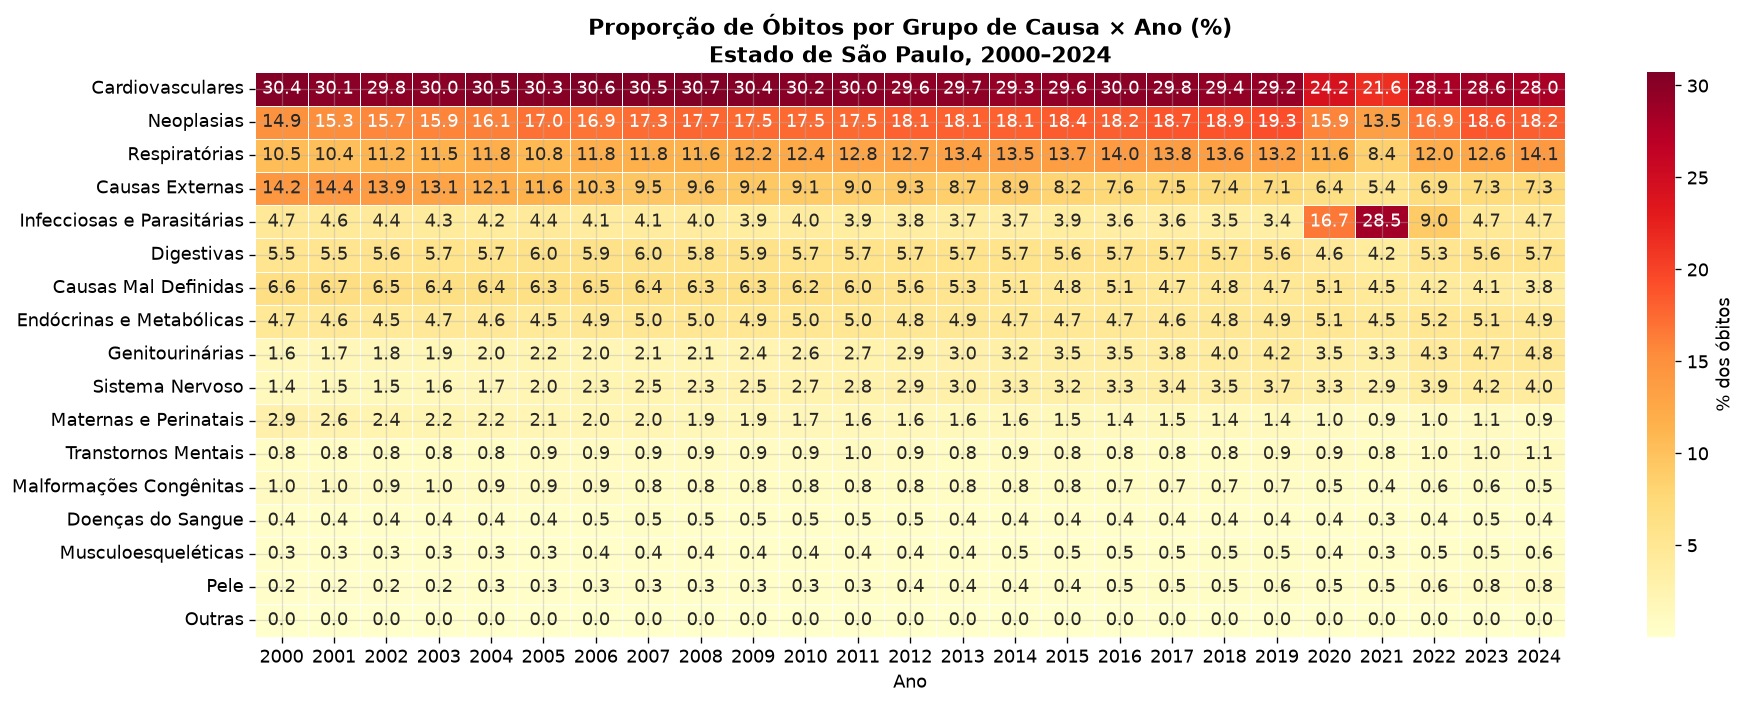

In [15]:
# Heatmap: proporção por grupo × ano
# Ordena grupos pelo valor médio (maior impacto primeiro)
ordem = pivot.mean().sort_values(ascending=False).index
pivot_ord = pivot[ordem]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_ord.T, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.3, ax=ax, cbar_kws={'label': '% dos óbitos'}
)
ax.set_title('Proporção de Óbitos por Grupo de Causa × Ano (%)\nEstado de São Paulo, 2000–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig(FIGURAS / 'fig03_heatmap_grupos_cid.png', bbox_inches='tight')
plt.show()

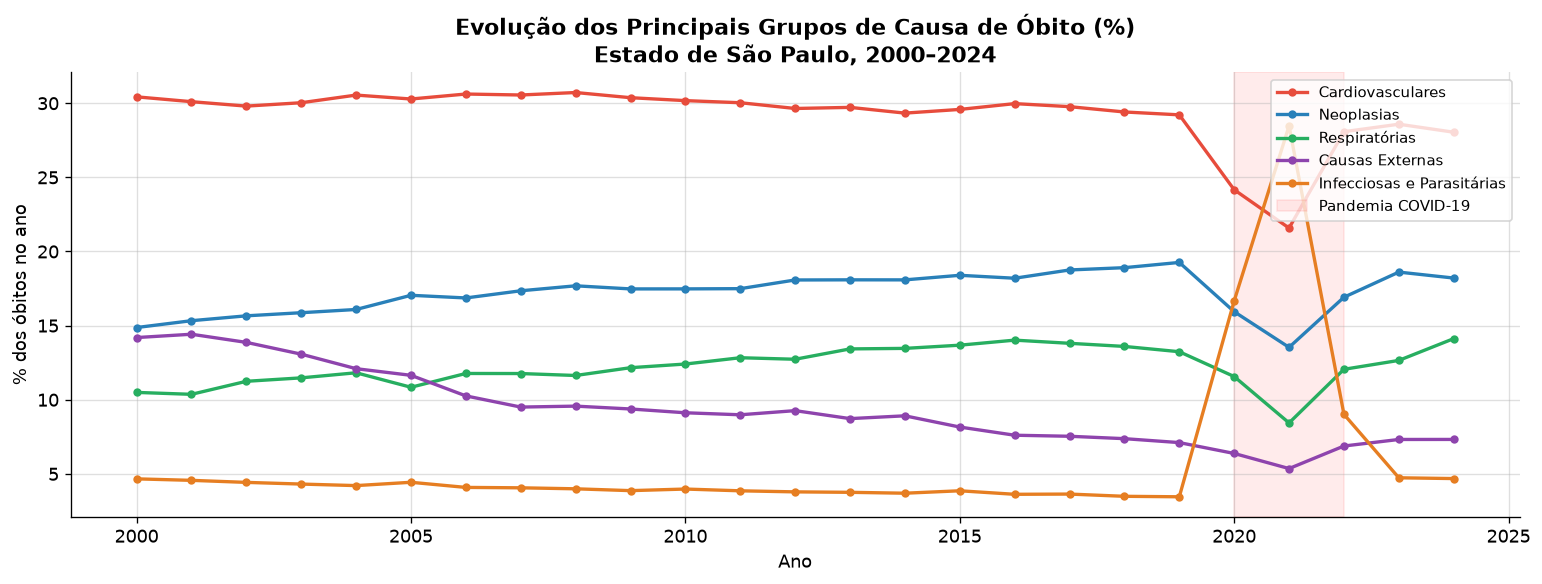

In [16]:
# Série temporal dos 5 principais grupos (proporção %)
TOP5 = pivot_ord.columns[:5].tolist()

CORES = [
    '#e74c3c', '#2980b9', '#27ae60', '#8e44ad', '#e67e22',
]

fig, ax = plt.subplots(figsize=(13, 5))
for i, grupo in enumerate(TOP5):
    ax.plot(pivot_ord.index, pivot_ord[grupo], marker='o', ms=4,
            linewidth=2, label=grupo, color=CORES[i])

# Evento COVID-19
ax.axvspan(2020, 2022, alpha=0.08, color='red', label='Pandemia COVID-19')

ax.set_title('Evolução dos Principais Grupos de Causa de Óbito (%)\nEstado de São Paulo, 2000–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos no ano')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURAS / 'fig04_series_grupos_cid.png', bbox_inches='tight')
plt.show()

In [17]:
from scipy import stats

In [18]:
# Teste de quebra estrutural simplificado: Infecciosas antes/depois de 2020
infec = pivot_ord.get('Infecciosas e Parasitárias', pd.Series(dtype=float))
if not infec.empty:
    antes  = infec[infec.index < 2020]
    depois = infec[infec.index >= 2020]
    t, p = stats.ttest_ind(antes, depois)
    print(f'Infecciosas e Parasitárias:')
    print(f'  Média 2000–2019: {antes.mean():.2f}%')
    print(f'  Média 2020–2024: {depois.mean():.2f}%')
    print(f'  t-test: t={t:.3f}, p={p:.4f}')
    if p < 0.05:
        print('  → Diferença estatisticamente significativa (p < 0.05)')
    else:
        print('  → Diferença NÃO significativa (p >= 0.05)')

Infecciosas e Parasitárias:
  Média 2000–2019: 3.98%
  Média 2020–2024: 12.71%
  t-test: t=-4.144, p=0.0004
  → Diferença estatisticamente significativa (p < 0.05)


---
## 4. Excesso de Mortalidade (COVID-19 e H1N1)
Baseline mensal 2015–2019 ± 2 desvios-padrão como limiar de excesso.

In [14]:
# Série mensal completa (usa df_full para incluir 2020–2022)
mensal = (
    df_full
    .assign(ANO=df_full['ANO'], MES=df_full['MES'])
    .groupby(['ANO', 'MES'])
    .size()
    .reset_index(name='obitos')
)

# Baseline: média e desvio padrão por mês (2015–2019)
baseline = (
    mensal[mensal['ANO'].between(2015, 2019)]
    .groupby('MES')['obitos']
    .agg(media='mean', desvio='std')
    .reset_index()
)

# Período de análise do excesso: 2018–2024
analise = mensal[mensal['ANO'].between(2018, 2024)].copy()
analise = analise.merge(baseline, on='MES')
analise['excesso']    = analise['obitos'] - analise['media']
analise['limite_sup'] = analise['media'] + 2 * analise['desvio']
analise['limite_inf'] = analise['media'] - 2 * analise['desvio']
analise['periodo']    = pd.to_datetime(
    analise['ANO'].astype(str) + '-' + analise['MES'].astype(str).str.zfill(2)
)
analise = analise.sort_values('periodo')

meses_excesso = (analise['obitos'] > analise['limite_sup']).sum()
print(f'Meses com excesso acima do limiar (μ + 2σ): {meses_excesso}')
analise[analise['obitos'] > analise['limite_sup']][['periodo','obitos','media','excesso']]

Meses com excesso acima do limiar (μ + 2σ): 59


,periodo,obitos,media,excesso
25,2020-02-01,23071,21354.4,1716.6
26,2020-03-01,26743,24121.0,2622.0
27,2020-04-01,27215,24132.4,3082.6
28,2020-05-01,32432,26075.8,6356.2
29,2020-06-01,32518,27019.0,5499.0
30,2020-07-01,33552,27715.0,5837.0
31,2020-08-01,32784,25865.2,6918.8
32,2020-09-01,29295,24412.4,4882.6
33,2020-10-01,29865,24356.0,5509.0
34,2020-11-01,27022,23093.6,3928.4


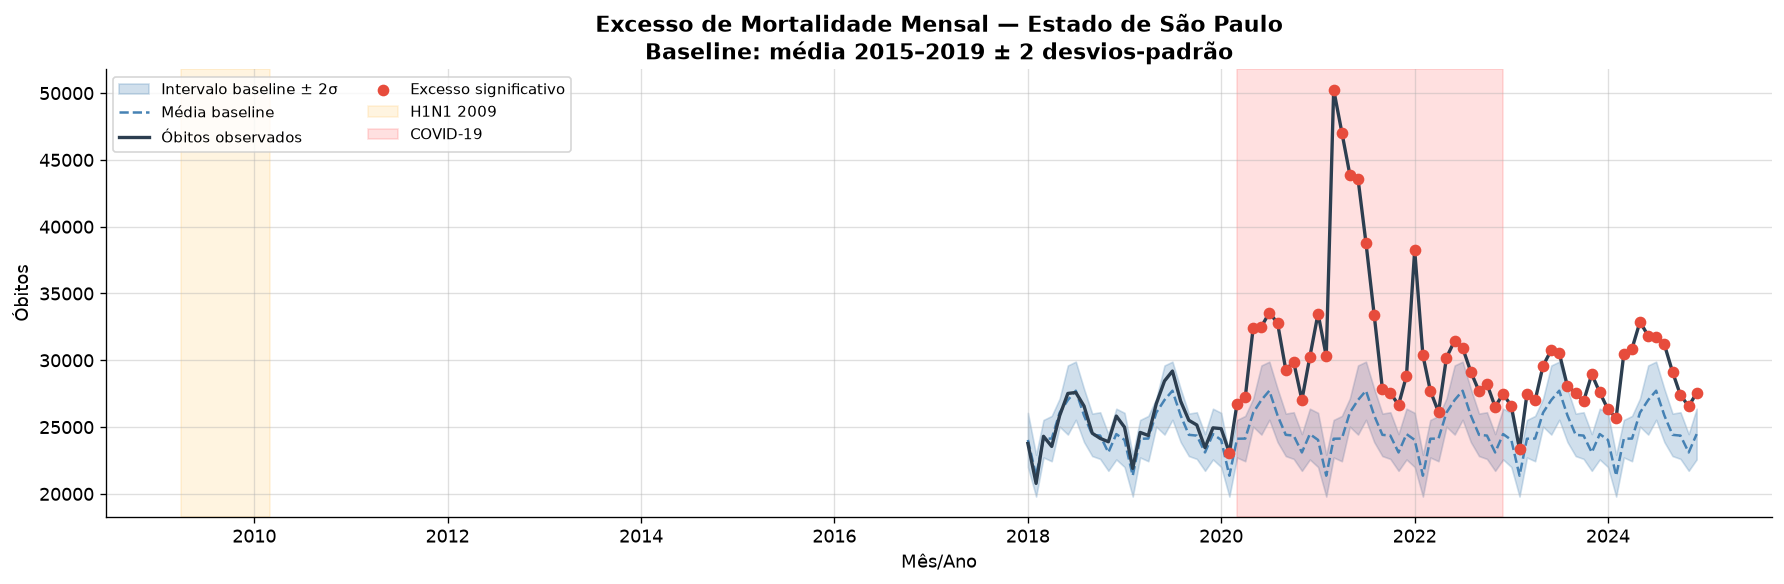

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(analise['periodo'], analise['limite_inf'], analise['limite_sup'],
                alpha=0.25, color='steelblue', label='Intervalo baseline ± 2σ')
ax.plot(analise['periodo'], analise['media'], '--', color='steelblue', linewidth=1.5, label='Média baseline')
ax.plot(analise['periodo'], analise['obitos'], color='#2c3e50', linewidth=2, label='Óbitos observados')

# Destaca pontos de excesso
excesso_mask = analise['obitos'] > analise['limite_sup']
ax.scatter(analise.loc[excesso_mask, 'periodo'], analise.loc[excesso_mask, 'obitos'],
           color='#e74c3c', zorder=5, label='Excesso significativo')

# Bandas de eventos
ax.axvspan(pd.Timestamp('2009-04-01'), pd.Timestamp('2010-03-01'),
           alpha=0.12, color='orange', label='H1N1 2009')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-12-01'),
           alpha=0.12, color='red', label='COVID-19')

ax.set_title('Excesso de Mortalidade Mensal — Estado de São Paulo\nBaseline: média 2015–2019 ± 2 desvios-padrão',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mês/Ano')
ax.set_ylabel('Óbitos')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
fig.savefig(FIGURAS / 'fig05_excess_mortality.png', bbox_inches='tight')
plt.show()

---
## 5. Perfil Demográfico

### 5.1 Idade ao óbito

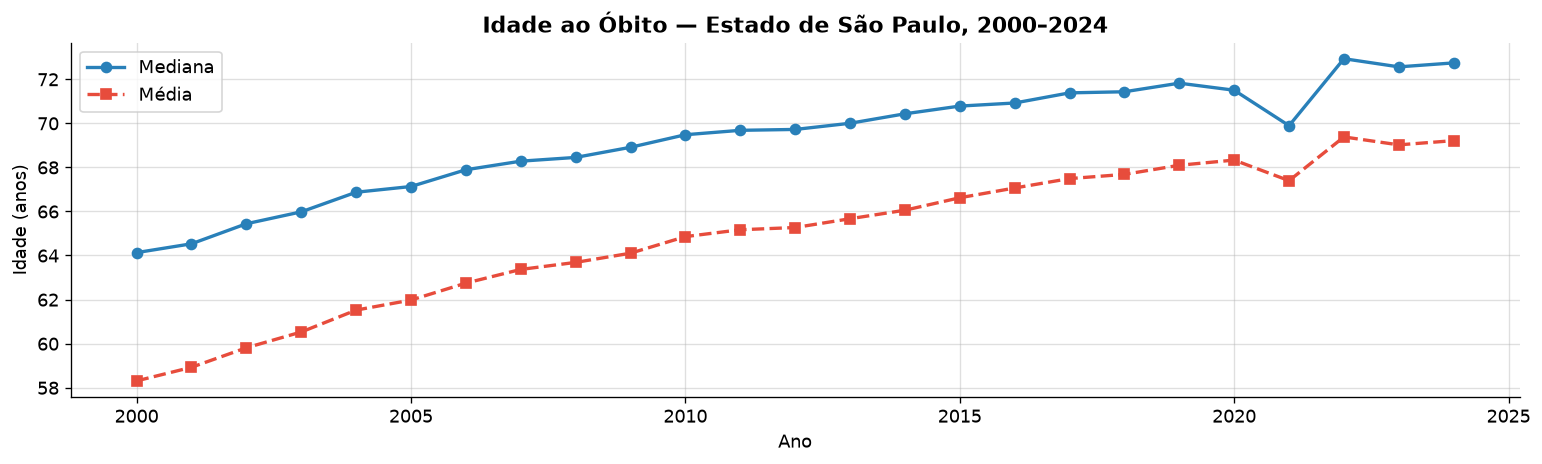

Ganho de anos (mediana 2000→2024): 8.6 anos


In [16]:
# Idade mediana e média ao óbito por ano
idade_ano = (
    df[df['IDADE'].between(0, 120)]
    .groupby('ANO')['IDADE']
    .agg(mediana='median', media='mean')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(idade_ano['ANO'], idade_ano['mediana'], marker='o', linewidth=2,
        color='#2980b9', label='Mediana')
ax.plot(idade_ano['ANO'], idade_ano['media'], marker='s', linewidth=2,
        color='#e74c3c', linestyle='--', label='Média')
ax.set_title('Idade ao Óbito — Estado de São Paulo, 2000–2024', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Idade (anos)')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig06_idade_obito.png', bbox_inches='tight')
plt.show()

print(f"Ganho de anos (mediana 2000→2024): "
      f"{idade_ano[idade_ano.ANO==2024]['mediana'].values[0] - idade_ano[idade_ano.ANO==2000]['mediana'].values[0]:.1f} anos")

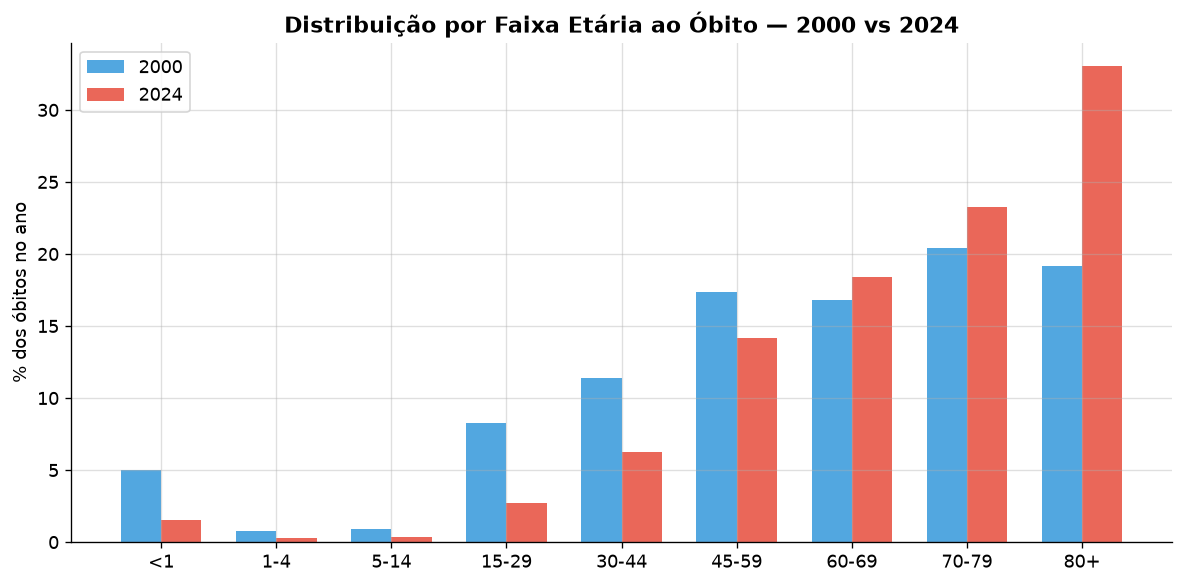

In [17]:
# Pirâmide de faixas etárias — comparação 2000 vs 2024
bins  = [0, 1, 5, 15, 30, 45, 60, 70, 80, 120]
labels = ['<1', '1-4', '5-14', '15-29', '30-44', '45-59', '60-69', '70-79', '80+']

def faixa_etaria(df_ano):
    d = df_ano[df_ano['IDADE'].between(0, 120)].copy()
    d['FAIXA'] = pd.cut(d['IDADE'], bins=bins, labels=labels, right=False)
    return d.groupby('FAIXA', observed=True).size() / len(d) * 100

f2000 = faixa_etaria(df[df['ANO'] == 2000])
f2024 = faixa_etaria(df[df['ANO'] == 2024])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, f2000.values, w, label='2000', color='#3498db', alpha=0.85)
ax.bar(x + w/2, f2024.values, w, label='2024', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Distribuição por Faixa Etária ao Óbito — 2000 vs 2024', fontweight='bold')
ax.set_ylabel('% dos óbitos no ano')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig07_faixas_etarias.png', bbox_inches='tight')
plt.show()

### 5.2 Sexo

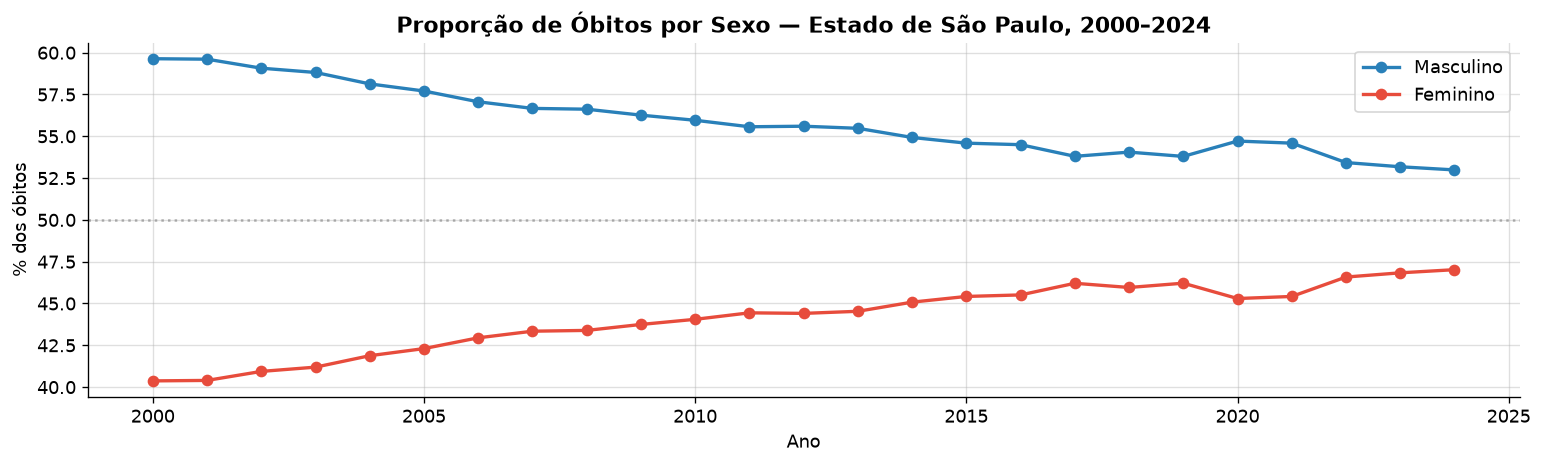

In [18]:
sexo_ano = (
    df[df['SEXO_NOME'].isin(['Masculino', 'Feminino'])]
    .groupby(['ANO', 'SEXO_NOME'])
    .size()
    .reset_index(name='n')
)
total_ano_sexo = sexo_ano.groupby('ANO')['n'].transform('sum')
sexo_ano['prop'] = sexo_ano['n'] / total_ano_sexo * 100

fig, ax = plt.subplots(figsize=(13, 4))
for sexo, cor in [('Masculino', '#2980b9'), ('Feminino', '#e74c3c')]:
    s = sexo_ano[sexo_ano['SEXO_NOME'] == sexo]
    ax.plot(s['ANO'], s['prop'], marker='o', linewidth=2, label=sexo, color=cor)

ax.axhline(50, color='grey', linestyle=':', alpha=0.6)
ax.set_title('Proporção de Óbitos por Sexo — Estado de São Paulo, 2000–2024', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig08_obitos_por_sexo.png', bbox_inches='tight')
plt.show()

### 5.3 Raça/Cor

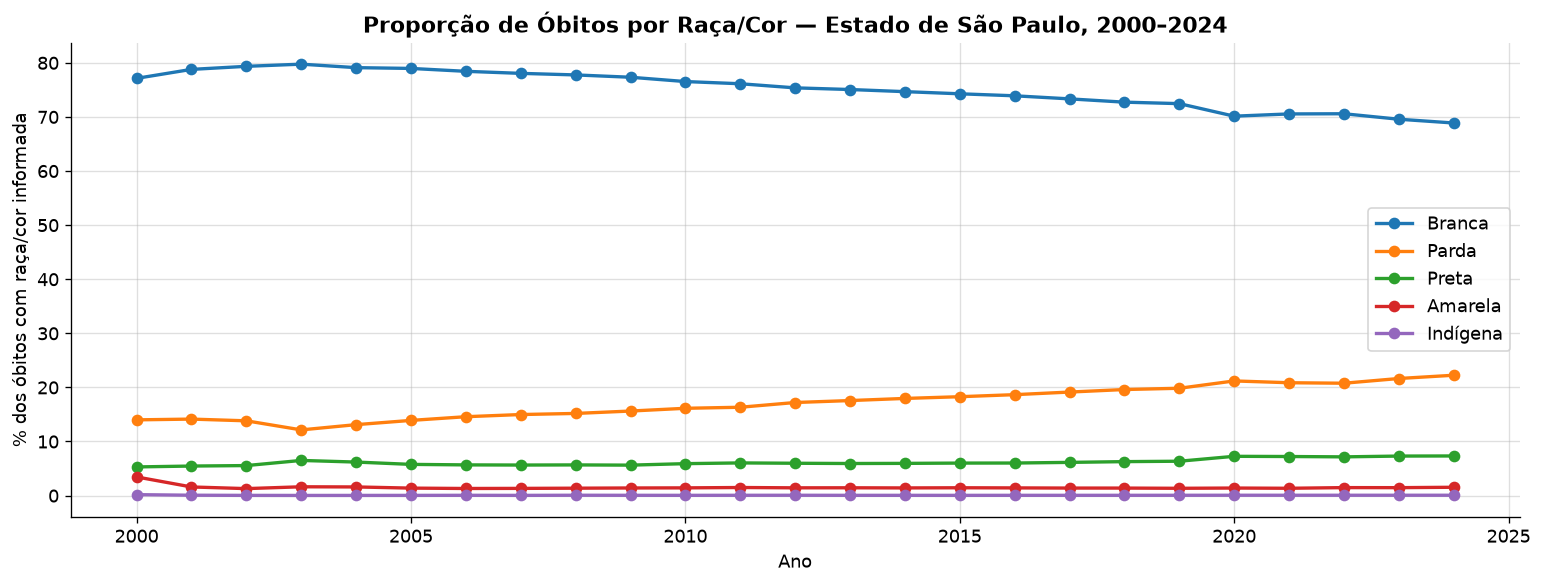

In [19]:
# Distribuição de raça/cor (excluindo nulos)
raca_total = (
    df[df['RACACOR_NOME'].notna()]
    .groupby(['ANO', 'RACACOR_NOME'])
    .size()
    .reset_index(name='n')
)
total_raca = raca_total.groupby('ANO')['n'].transform('sum')
raca_total['prop'] = raca_total['n'] / total_raca * 100

fig, ax = plt.subplots(figsize=(13, 5))
for raca in ['Branca', 'Parda', 'Preta', 'Amarela', 'Indígena']:
    s = raca_total[raca_total['RACACOR_NOME'] == raca]
    if not s.empty:
        ax.plot(s['ANO'], s['prop'], marker='o', linewidth=2, label=raca)

ax.set_title('Proporção de Óbitos por Raça/Cor — Estado de São Paulo, 2000–2024', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos com raça/cor informada')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig09_obitos_por_raca.png', bbox_inches='tight')
plt.show()

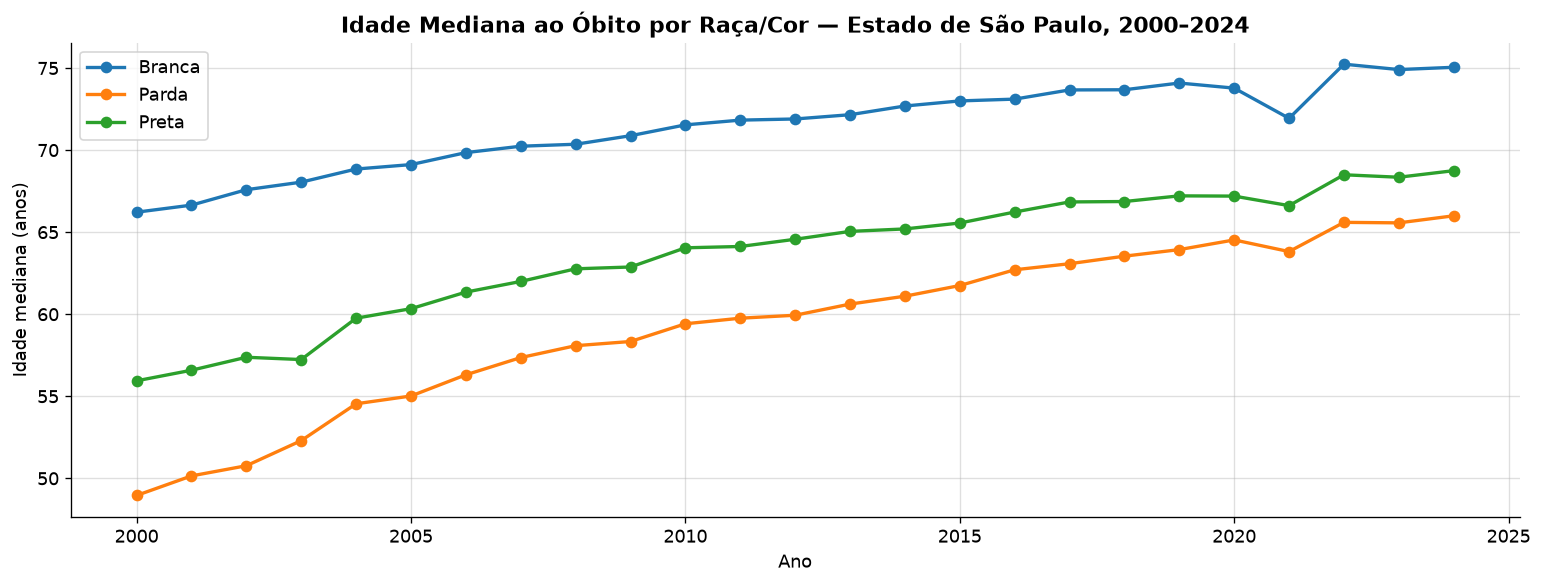

In [20]:
# Idade mediana ao óbito por raça/cor — indicador de desigualdade
mediana_raca = (
    df[df['RACACOR_NOME'].notna() & df['IDADE'].between(0, 120)]
    .groupby(['ANO', 'RACACOR_NOME'])['IDADE']
    .median()
    .reset_index(name='idade_mediana')
)

fig, ax = plt.subplots(figsize=(13, 5))
for raca in ['Branca', 'Parda', 'Preta']:
    s = mediana_raca[mediana_raca['RACACOR_NOME'] == raca]
    if not s.empty:
        ax.plot(s['ANO'], s['idade_mediana'], marker='o', linewidth=2, label=raca)

ax.set_title('Idade Mediana ao Óbito por Raça/Cor — Estado de São Paulo, 2000–2024',
             fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Idade mediana (anos)')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS / 'fig10_idade_mediana_raca.png', bbox_inches='tight')
plt.show()

### 5.4 Escolaridade
> `ESC2010` disponível principalmente pós-2010. Análise restrita a 2011–2024.

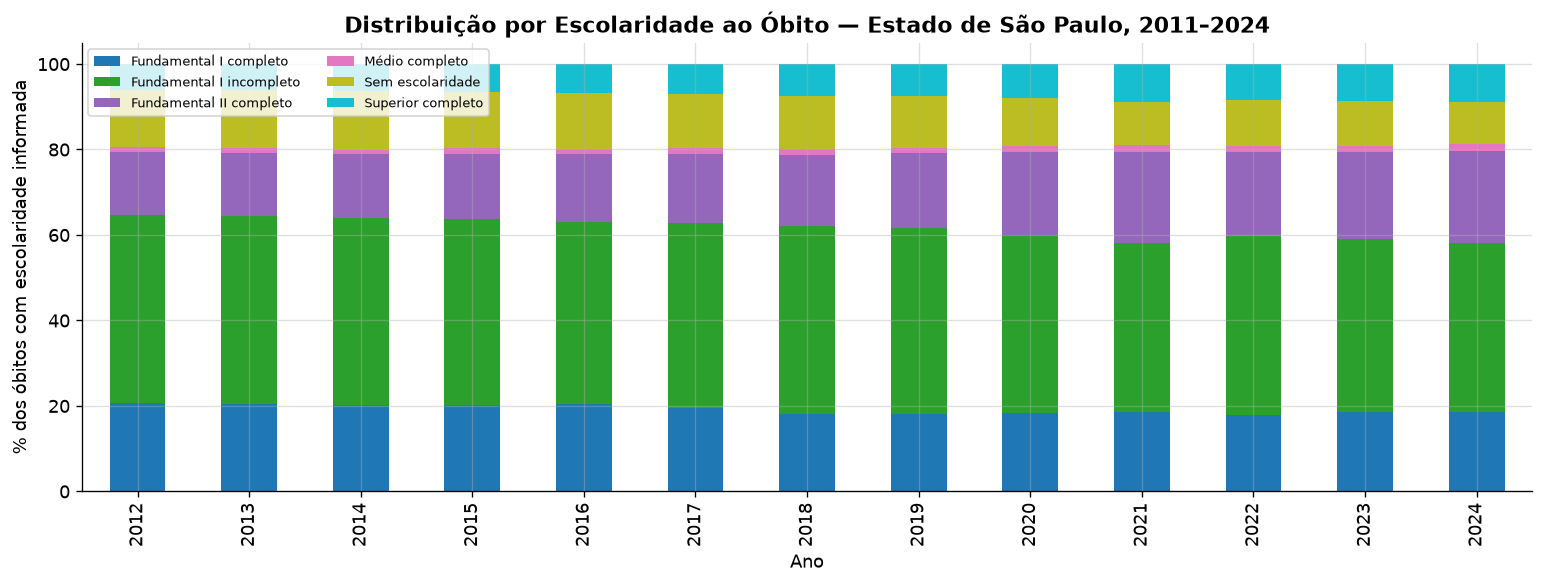

In [21]:
ESC2010_MAP = {
    '0': 'Sem escolaridade',
    '1': 'Fundamental I incompleto',
    '2': 'Fundamental I completo',
    '3': 'Fundamental II completo',
    '4': 'Médio completo',
    '5': 'Superior completo',
     0:  'Sem escolaridade',
     1:  'Fundamental I incompleto',
     2:  'Fundamental I completo',
     3:  'Fundamental II completo',
     4:  'Médio completo',
     5:  'Superior completo',
}

df_esc = df[(df['ANO'] >= 2011) & (df['ESC2010'].notna())].copy()
df_esc['ESC2010_NOME'] = df_esc['ESC2010'].map(ESC2010_MAP)

esc_ano = (
    df_esc[df_esc['ESC2010_NOME'].notna()]
    .groupby(['ANO', 'ESC2010_NOME'])
    .size()
    .reset_index(name='n')
)
total_esc = esc_ano.groupby('ANO')['n'].transform('sum')
esc_ano['prop'] = esc_ano['n'] / total_esc * 100

pivot_esc = esc_ano.pivot(index='ANO', columns='ESC2010_NOME', values='prop').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_esc.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Distribuição por Escolaridade ao Óbito — Estado de São Paulo, 2011–2024',
             fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos com escolaridade informada')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(FIGURAS / 'fig11_escolaridade.png', bbox_inches='tight')
plt.show()

---
## 6. Top 10 Causas de Óbito
Ranking dos códigos CID-10 mais frequentes em 2000 e 2024.

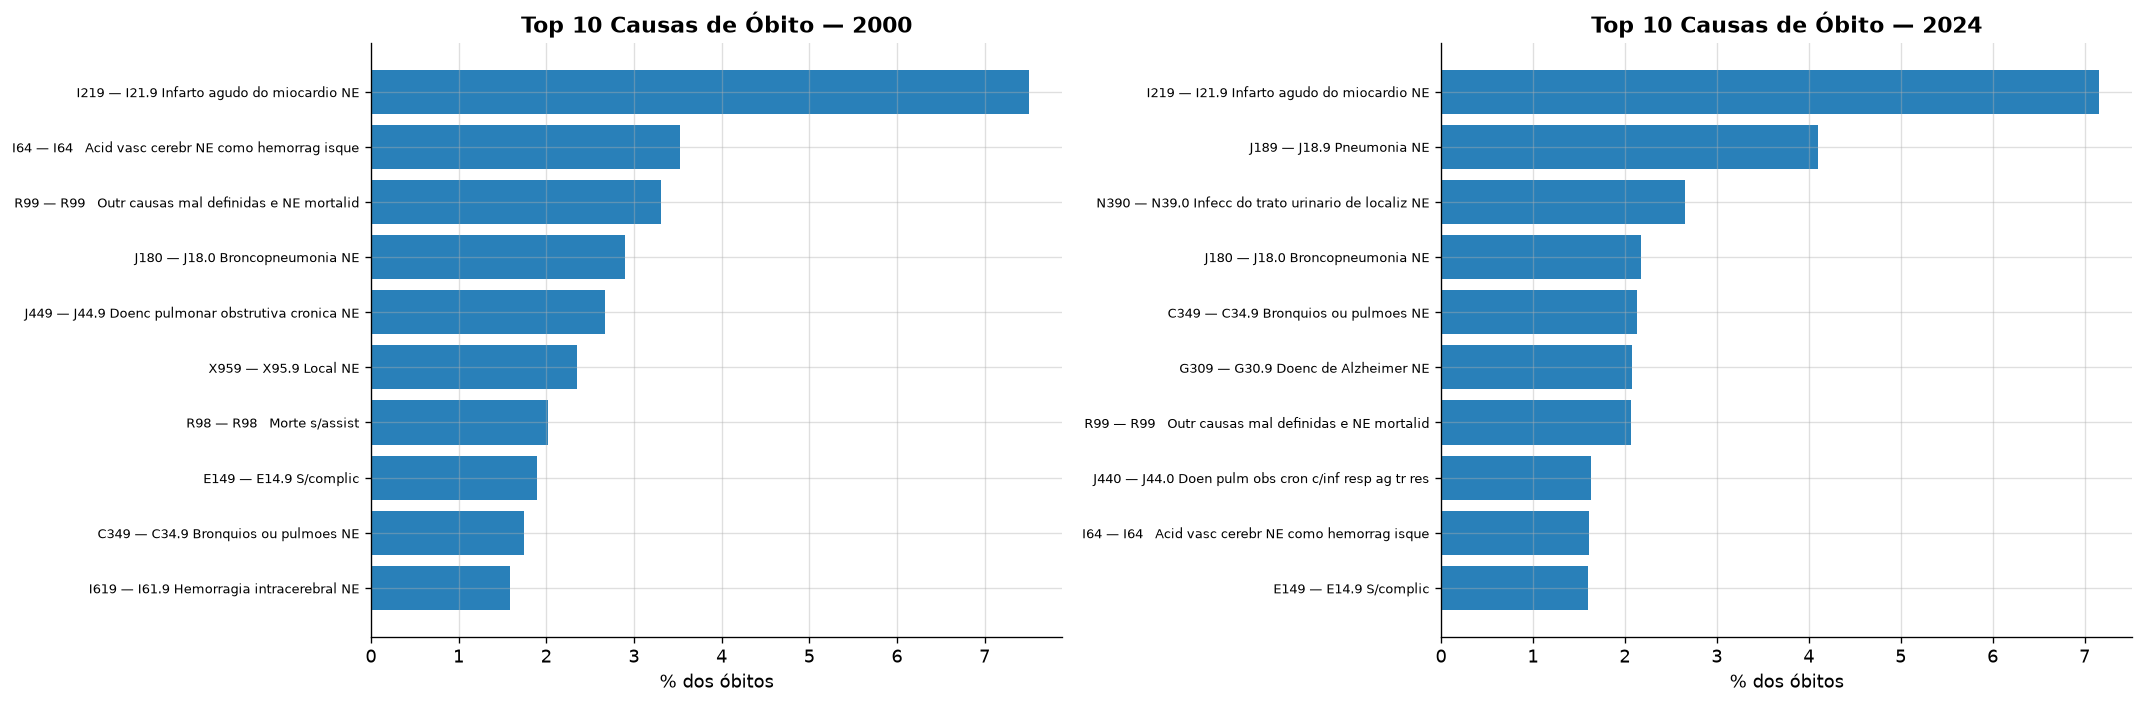


--- Top 10 em 2000 ---
CAUSABAS                                             DESCR     n        %
    I219               I21.9 Infarto agudo do miocardio NE 17940 7.511053
     I64 I64   Acid vasc cerebr NE como hemorrag isquemico  8427 3.528185
     R99  R99   Outr causas mal definidas e NE mortalidade  7903 3.308799
    J180                          J18.0 Broncopneumonia NE  6930 2.901427
    J449        J44.9 Doenc pulmonar obstrutiva cronica NE  6385 2.673248
    X959                                    X95.9 Local NE  5626 2.355473
     R98                              R98   Morte s/assist  4816 2.016345
    E149                                   E14.9 S/complic  4526 1.894929
    C349                     C34.9 Bronquios ou pulmoes NE  4169 1.745462
    I619                 I61.9 Hemorragia intracerebral NE  3787 1.585527

--- Top 10 em 2024 ---
CAUSABAS                                              DESCR     n        %
    I219                I21.9 Infarto agudo do miocardio NE 251

In [22]:
def top10_causas(ano):
    sub = df[df['ANO'] == ano]
    top = (
        sub.groupby(['CAUSABAS', 'DESCR'])
           .size()
           .reset_index(name='n')
           .sort_values('n', ascending=False)
           .head(10)
    )
    top['%'] = top['n'] / len(sub) * 100
    top['rotulo'] = top.apply(
        lambda r: f"{r['CAUSABAS']} — {r['DESCR'][:45]}" if pd.notna(r['DESCR'])
                  else r['CAUSABAS'], axis=1
    )
    return top

top_2000 = top10_causas(2000)
top_2024 = top10_causas(2024)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, top, ano in zip(axes, [top_2000, top_2024], [2000, 2024]):
    ax.barh(top['rotulo'][::-1], top['%'][::-1], color='#2980b9')
    ax.set_title(f'Top 10 Causas de Óbito — {ano}', fontweight='bold')
    ax.set_xlabel('% dos óbitos')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
fig.savefig(FIGURAS / 'fig12_top10_causas.png', bbox_inches='tight')
plt.show()

print('\n--- Top 10 em 2000 ---')
print(top_2000[['CAUSABAS','DESCR','n','%']].to_string(index=False))
print('\n--- Top 10 em 2024 ---')
print(top_2024[['CAUSABAS','DESCR','n','%']].to_string(index=False))

---
## 7. Município e Região
Distribuição geográfica — capitais vs. interior.

 ANO        LOCAL      n      prop
2000 Capital (SP)  68319 28.603547
2000     Interior 170529 71.396453



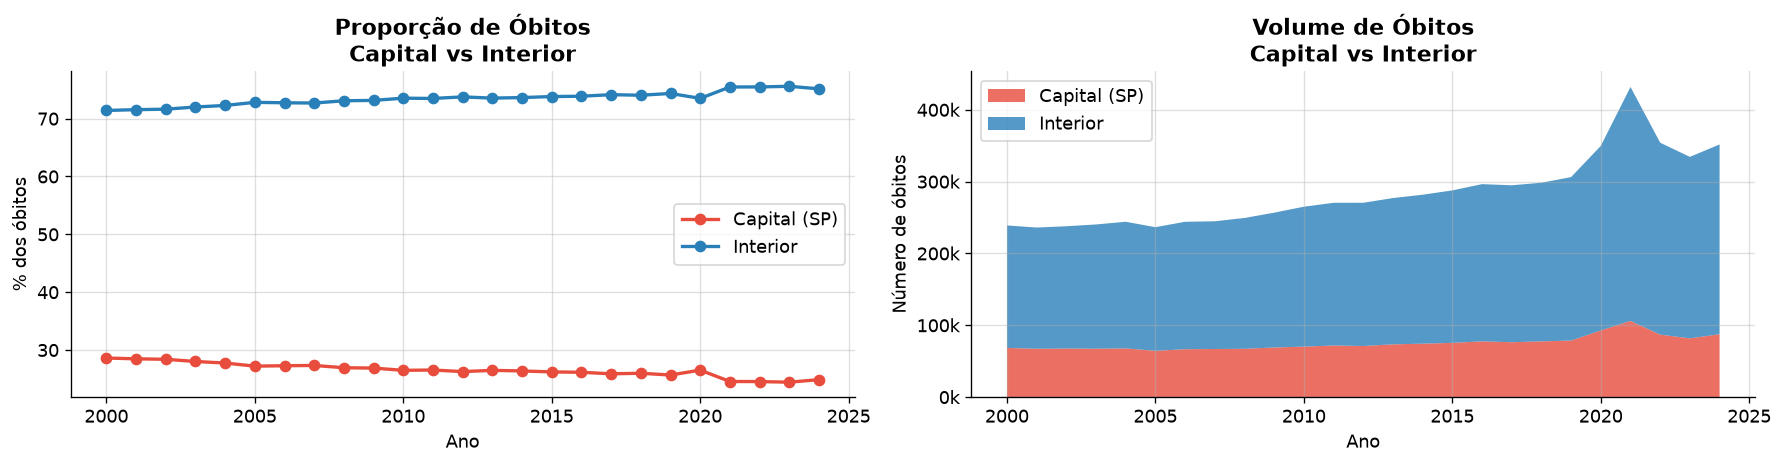

In [9]:
# Proporção Capital (município de São Paulo) vs Interior ao longo do tempo
# CAPITAL: 'S' = São Paulo capital, 'N' = demais municípios
geo_ano = (
    df.assign(LOCAL=df['CAPITAL'].astype(str).str.strip()
              .map({'S': 'Capital (SP)', 'N': 'Interior'})
              .fillna('Interior'))
    .groupby(['ANO', 'LOCAL'])
    .size()
    .reset_index(name='n')
)
total_geo = geo_ano.groupby('ANO')['n'].transform('sum')
geo_ano['prop'] = geo_ano['n'] / total_geo * 100

# Verificação rápida
print(geo_ano[geo_ano['ANO'] == 2000].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Painel 1: proporção
ax = axes[0]
for local, cor in [('Capital (SP)', '#e74c3c'), ('Interior', '#2980b9')]:
    s = geo_ano[geo_ano['LOCAL'] == local]
    ax.plot(s['ANO'], s['prop'], marker='o', linewidth=2, label=local, color=cor)
ax.set_title('Proporção de Óbitos\nCapital vs Interior', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos')
ax.legend()

# Painel 2: volume absoluto
ax2 = axes[1]
pivot_geo = geo_ano.pivot(index='ANO', columns='LOCAL', values='n').fillna(0)
ax2.stackplot(pivot_geo.index,
              pivot_geo.get('Capital (SP)', 0),
              pivot_geo.get('Interior', 0),
              labels=['Capital (SP)', 'Interior'],
              colors=['#e74c3c', '#2980b9'], alpha=0.8)
ax2.set_title('Volume de Óbitos\nCapital vs Interior', fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Número de óbitos')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}k'))
ax2.legend(loc='upper left')

plt.tight_layout()
fig.savefig(FIGURAS / 'fig13_capital_vs_interior.png', bbox_inches='tight')
plt.show()

---
## 8. Sumário dos Resultados
Tabela consolidada para exportação / monografia.

In [24]:
# Tabela resumo anual: total de óbitos, idade mediana, % grupos principais
grupos_principais = ['Cardiovasculares', 'Neoplasias', 'Infecciosas e Parasitárias',
                     'Causas Externas', 'Respiratórias', 'Causas Mal Definidas']

resumo = obitos_ano[obitos_ano['ANO'] <= 2024][['ANO', 'obitos']].copy()
resumo = resumo.merge(idade_ano[['ANO', 'mediana']].rename(columns={'mediana': 'idade_mediana'}), on='ANO')

for g in grupos_principais:
    col = g.lower().replace(' ', '_').replace('/', '')
    vals = pivot_ord[g] if g in pivot_ord.columns else pd.Series(dtype=float)
    if not vals.empty:
        resumo = resumo.merge(
            vals.reset_index().rename(columns={g: col, 'ANO': 'ANO'}),
            on='ANO', how='left'
        )

resumo.to_csv('variavel/resumo_anual.csv', index=False, sep=';', decimal=',')
print('Tabela salva em variavel/resumo_anual.csv')
resumo.tail(10)

Tabela salva em variavel/resumo_anual.csv


,ANO,obitos,idade_mediana,cardiovasculares,neoplasias,infecciosas_e_parasitárias,causas_externas,respiratórias,causas_mal_definidas
15,2015,287639,70.78,29.575614,18.387284,3.852746,8.151537,13.673389,4.776821
16,2016,296353,70.92,29.967303,18.189794,3.615283,7.600058,14.013356,5.065581
17,2017,294746,71.38,29.762575,18.746989,3.630584,7.529534,13.800018,4.693193
18,2018,298301,71.43,29.403857,18.901713,3.480042,7.368396,13.589629,4.833038
19,2019,306183,71.82,29.210635,19.254825,3.447611,7.103268,13.232936,4.739976
20,2020,349629,71.50,24.159037,15.932889,16.661947,6.370467,11.557680,5.116566
21,2021,431603,69.89,21.574224,13.527709,28.467365,5.351446,8.429738,4.493945
22,2022,354046,72.93,28.073188,16.907690,9.010129,6.871988,12.047022,4.231089
23,2023,334296,72.56,28.578565,18.603573,4.729043,7.313578,12.645978,4.077225
24,2024,351603,72.74,28.039010,18.201779,4.676297,7.316490,14.115067,3.826759


---
## 9. Tendências de Longo Prazo por Grupo de Causa
Regressão linear sobre o período estrutural 2000–2024, excluindo 2020–2021 (distorção pandêmica).  
Projeção do ponto de cruzamento entre Cardiovasculares e Neoplasias.

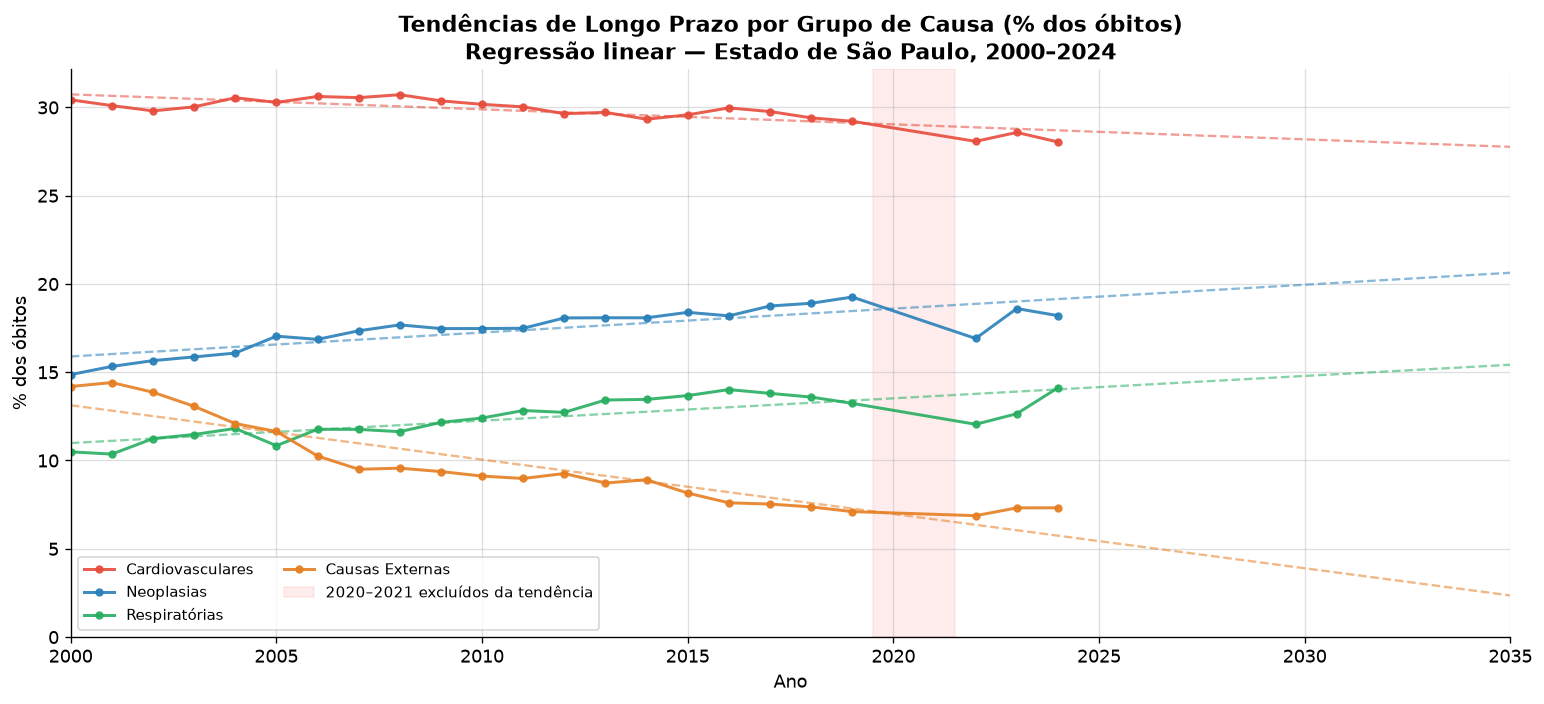

Grupo                           Slope (%/ano)     R²    p-valor    Tendência
----------------------------------------------------------------------------
Cardiovasculares                      -0.0849  0.670     0.0000  decrescente ***
Neoplasias                            +0.1354  0.671     0.0000  crescente ***
Respiratórias                         +0.1267  0.651     0.0000  crescente ***
Causas Externas                       -0.3078  0.855     0.0000  decrescente ***


In [19]:
from scipy.stats import linregress

# Exclui 2020-2021 para não distorcer a tendência estrutural
ANOS_EXCLUIR = [2020, 2021]
df_trend = pivot_ord.drop(index=ANOS_EXCLUIR, errors='ignore')

GRUPOS_TREND = ['Cardiovasculares', 'Neoplasias', 'Respiratórias', 'Causas Externas']
CORES_TREND  = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(13, 6))
resultados = {}

for grupo, cor in zip(GRUPOS_TREND, CORES_TREND):
    if grupo not in df_trend.columns:
        continue
    y = df_trend[grupo].values.astype(float)
    x = df_trend.index.values.astype(float)
    slope, intercept, r, p_val, _ = linregress(x, y)
    resultados[grupo] = dict(slope=slope, intercept=intercept, r2=r**2, p=p_val)

    # Série observada
    ax.plot(df_trend.index, y, marker='o', ms=4, linewidth=1.8,
            color=cor, label=grupo, alpha=0.9)
    # Linha de tendência projetada até 2035
    x_proj = np.arange(2000, 2036)
    ax.plot(x_proj, intercept + slope * x_proj, '--', linewidth=1.4, color=cor, alpha=0.55)

# Projeção de cruzamento Cardiovasculares × Neoplasias
rc = resultados.get('Cardiovasculares', {})
rn = resultados.get('Neoplasias', {})
if rc and rn and (rc['slope'] - rn['slope']) != 0:
    x_cross = (rn['intercept'] - rc['intercept']) / (rc['slope'] - rn['slope'])
    y_cross = rc['intercept'] + rc['slope'] * x_cross
    if 2025 <= x_cross <= 2040:
        ax.axvline(x_cross, color='grey', linestyle=':', alpha=0.7)
        ax.annotate(f'Cruzamento\n~{x_cross:.0f}',
                    xy=(x_cross, y_cross), xytext=(x_cross + 0.5, y_cross + 1.5),
                    fontsize=9, color='grey',
                    arrowprops=dict(arrowstyle='->', color='grey', lw=1))

# Marca anos pandêmicos excluídos
ax.axvspan(2019.5, 2021.5, alpha=0.07, color='red', label='2020–2021 excluídos da tendência')

ax.set_xlim(2000, 2035)
ax.set_ylim(0)
ax.set_title('Tendências de Longo Prazo por Grupo de Causa (% dos óbitos)\n'
             'Regressão linear — Estado de São Paulo, 2000–2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
fig.savefig(FIGURAS / 'fig14_tendencias_grupos.png', bbox_inches='tight')
plt.show()

print(f'{"Grupo":<30} {"Slope (%/ano)":>14} {"R²":>6} {"p-valor":>10} {"Tendência":>12}')
print('-' * 76)
for grupo, r in resultados.items():
    tend = 'crescente' if r['slope'] > 0 else 'decrescente'
    sig  = '***' if r['p'] < 0.001 else ('**' if r['p'] < 0.01 else ('*' if r['p'] < 0.05 else 'ns'))
    print(f'{grupo:<30} {r["slope"]:>+14.4f} {r["r2"]:>6.3f} {r["p"]:>10.4f}  {tend} {sig}')

if rc and rn and 2025 <= x_cross <= 2040:
    print(f'\nProjeção: Neoplasias ultrapassam Cardiovasculares em ~{x_cross:.0f} ({y_cross:.1f}%)')

---
## 10. Padronização Etária (proxy por faixas)
Distribuição etária dos óbitos por grupo de causa — controle visual do efeito de envelhecimento.  
> Nota: padronização direta completa exige população por faixa etária do IBGE (não disponível nesta base).  
> Este proxy usa a composição etária dos próprios óbitos para evidenciar o deslocamento estrutural.

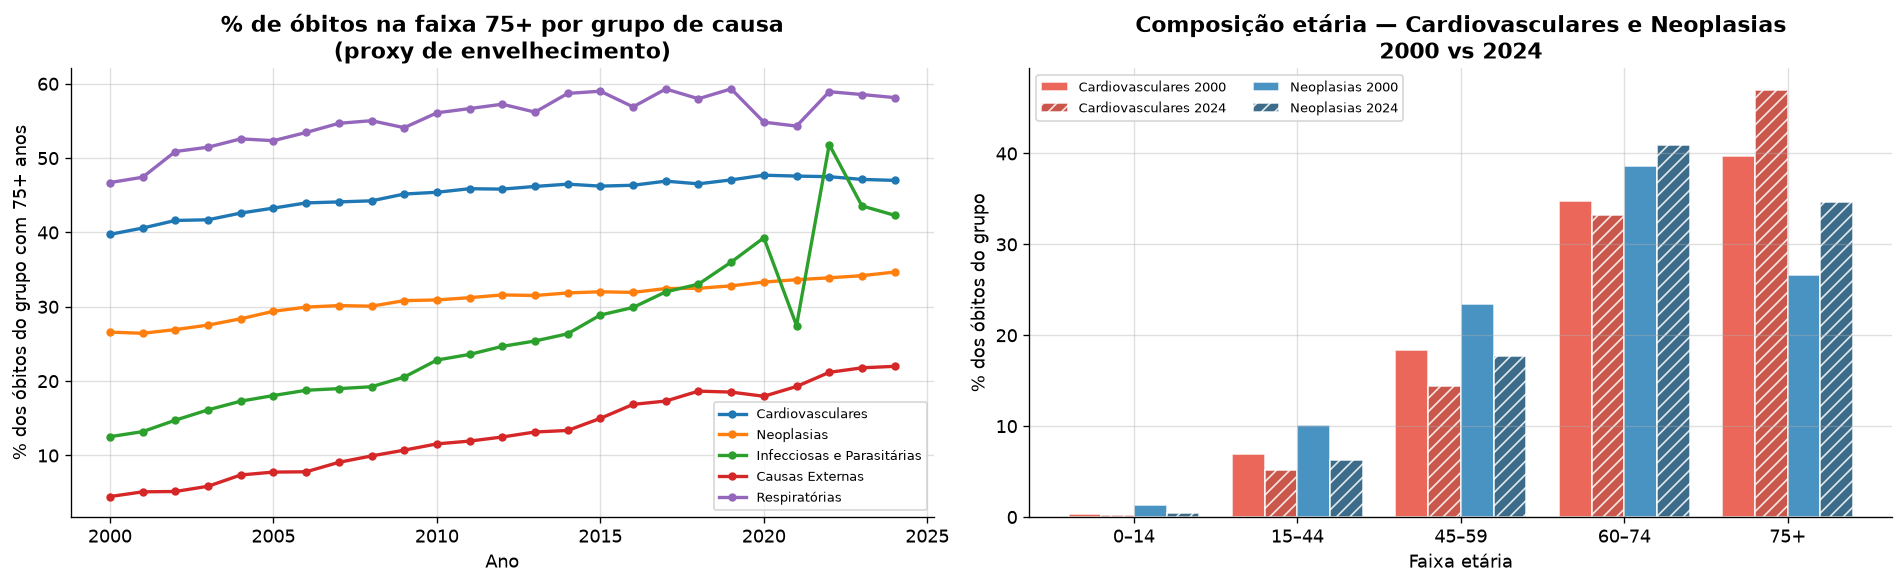

Grupo                                Mediana 2000  Mediana 2024      Δ
----------------------------------------------------------------------
Cardiovasculares                             71.2          73.9   +2.6
Neoplasias                                   66.5          69.8   +3.3
Infecciosas e Parasitárias                   44.7          71.1  +26.4
Causas Externas                              29.9          50.0  +20.1
Respiratórias                                73.7          78.1   +4.4


In [20]:
# Faixas etárias e grupos de causa de interesse
BINS_ET   = [0, 15, 45, 60, 75, 120]
LABELS_ET = ['0–14', '15–44', '45–59', '60–74', '75+']

GRUPOS_ET = ['Cardiovasculares', 'Neoplasias', 'Infecciosas e Parasitárias',
             'Causas Externas', 'Respiratórias']

df_et = df[df['IDADE'].between(0, 120) & df['GRUPO_CAUSA'].isin(GRUPOS_ET)].copy()
df_et['FAIXA'] = pd.cut(df_et['IDADE'], bins=BINS_ET, labels=LABELS_ET, right=False)

# Proporção de cada faixa dentro de cada grupo × ano
pivot_et = (
    df_et.groupby(['ANO', 'GRUPO_CAUSA', 'FAIXA'], observed=True)
         .size()
         .reset_index(name='n')
)
total_gc_ano = pivot_et.groupby(['ANO', 'GRUPO_CAUSA'])['n'].transform('sum')
pivot_et['prop'] = pivot_et['n'] / total_gc_ano * 100

# Série da faixa 75+ por grupo — indicador de envelhecimento da causa
serie_75 = (
    pivot_et[pivot_et['FAIXA'] == '75+']
    .pivot(index='ANO', columns='GRUPO_CAUSA', values='prop')
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Painel 1: % de óbitos na faixa 75+ por grupo
ax = axes[0]
for grupo in GRUPOS_ET:
    if grupo in serie_75.columns:
        ax.plot(serie_75.index, serie_75[grupo], marker='o', ms=4,
                linewidth=2, label=grupo)
ax.set_title('% de óbitos na faixa 75+ por grupo de causa\n(proxy de envelhecimento)',
             fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos do grupo com 75+ anos')
ax.legend(fontsize=8)

# Painel 2: composição etária dos óbitos em 2000 vs 2024 — Cardiovasculares × Neoplasias
ax2 = axes[1]
x = np.arange(len(LABELS_ET))
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
pares = [('Cardiovasculares', 2000), ('Cardiovasculares', 2024),
         ('Neoplasias', 2000),        ('Neoplasias', 2024)]
cores_pares = ['#e74c3c', '#c0392b', '#2980b9', '#1a5276']
hatch_pares = ['', '///', '', '///']

for (grupo, ano), cor, hatch, off in zip(pares, cores_pares, hatch_pares, offsets):
    vals = (
        pivot_et[(pivot_et['GRUPO_CAUSA'] == grupo) & (pivot_et['ANO'] == ano)]
        .set_index('FAIXA')['prop']
        .reindex(LABELS_ET, fill_value=0)
        .values
    )
    ax2.bar(x + off * w, vals, w, label=f'{grupo} {ano}',
            color=cor, hatch=hatch, alpha=0.85, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(LABELS_ET)
ax2.set_title('Composição etária — Cardiovasculares e Neoplasias\n2000 vs 2024',
              fontweight='bold')
ax2.set_xlabel('Faixa etária')
ax2.set_ylabel('% dos óbitos do grupo')
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout()
fig.savefig(FIGURAS / 'fig15_padronizacao_etaria_proxy.png', bbox_inches='tight')
plt.show()

# Resumo numérico: idade mediana por grupo em 2000 e 2024
print(f'{"Grupo":<35} {"Mediana 2000":>13} {"Mediana 2024":>13} {"Δ":>6}')
print('-' * 70)
for grupo in GRUPOS_ET:
    m2000 = df[(df['ANO']==2000) & (df['GRUPO_CAUSA']==grupo) & df['IDADE'].between(0,120)]['IDADE'].median()
    m2024 = df[(df['ANO']==2024) & (df['GRUPO_CAUSA']==grupo) & df['IDADE'].between(0,120)]['IDADE'].median()
    if not (np.isnan(m2000) or np.isnan(m2024)):
        print(f'{grupo:<35} {m2000:>13.1f} {m2024:>13.1f} {m2024-m2000:>+6.1f}')

---
## 11. Desigualdade Racial — Teste de Kruskal-Wallis
Teste não-paramétrico se a idade ao óbito difere significativamente entre grupos raciais.  
Comparações pós-hoc pairwise com Mann-Whitney + correção de Bonferroni.

Kruskal-Wallis  H=221697.94  p=0.00e+00

Par                               U     p bruto      p Bonf  Sig?
--------------------------------------------------------------
Branca vs Parda        3885004237896    0.00e+00    0.00e+00  ***
Branca vs Preta        1279256463094    0.00e+00    0.00e+00  ***
Parda vs Preta         228836413646    0.00e+00    0.00e+00  ***


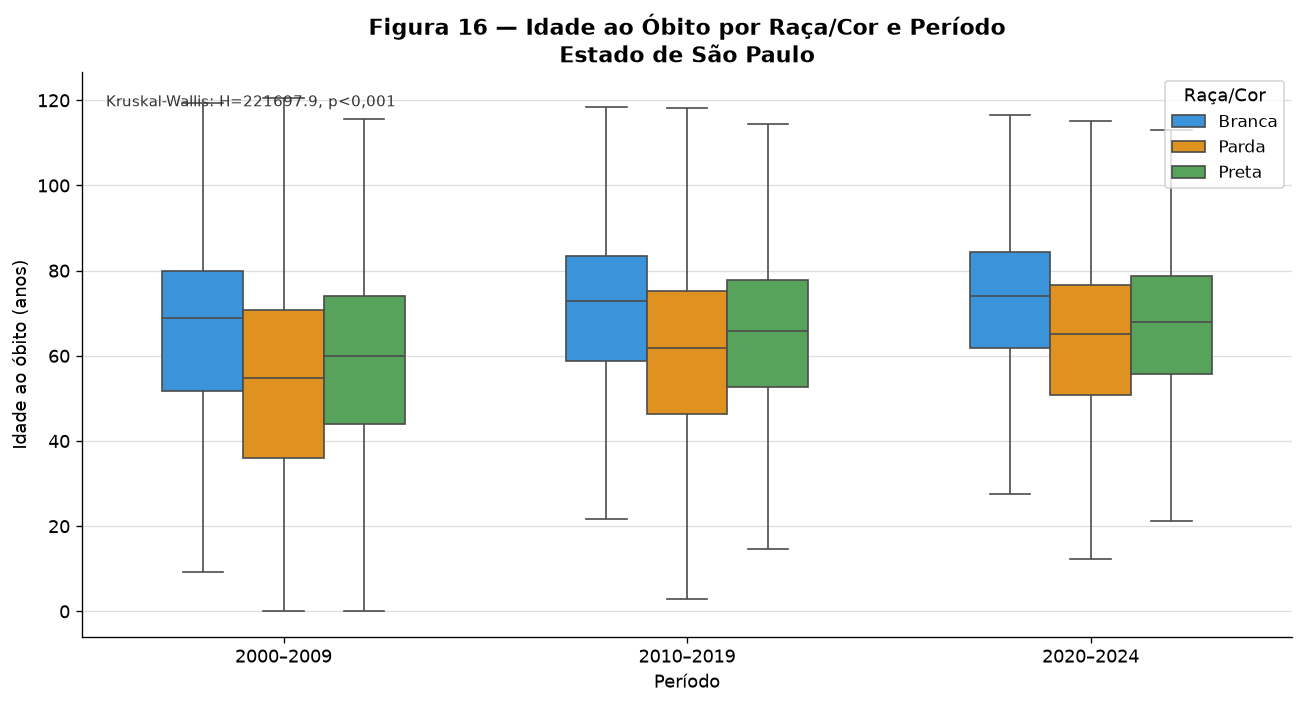

fig16 salva.

Mediana da idade ao óbito por raça/cor e ano:
RACACOR_NOME  Branca  Parda  Preta
ANO                               
2000            66.2   49.0   55.9
2001            66.6   50.1   56.6
2002            67.6   50.8   57.4
2003            68.0   52.3   57.2
2004            68.8   54.5   59.8
2005            69.1   55.0   60.3
2006            69.8   56.3   61.3
2007            70.2   57.4   62.0
2008            70.4   58.1   62.8
2009            70.9   58.3   62.9
2010            71.5   59.4   64.0
2011            71.8   59.8   64.1
2012            71.9   59.9   64.6
2013            72.2   60.6   65.0
2014            72.7   61.1   65.2
2015            73.0   61.7   65.6
2016            73.1   62.7   66.2
2017            73.7   63.1   66.8
2018            73.7   63.5   66.9
2019            74.1   63.9   67.2
2020            73.8   64.5   67.2
2021            71.9   63.8   66.6
2022            75.2   65.6   68.5
2023            74.9   65.6   68.3
2024            75.0   66.0   

In [21]:

# ── Seção 11: Desigualdade Racial ─────────────────────────────────────────────
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

RACAS_FOCO = ['Branca', 'Parda', 'Preta']

df_raca = (
    df.dropna(subset=['RACACOR_NOME', 'IDADE'])
      .query("RACACOR_NOME in @RACAS_FOCO")
      .assign(PERIODO=lambda x: pd.cut(
          x['ANO'],
          bins=[1999, 2009, 2019, 2025],
          labels=['2000–2009', '2010–2019', '2020–2024']))
)

# ── Kruskal-Wallis global ─────────────────────────────────────────────────────
grupos_kw = [df_raca.loc[df_raca['RACACOR_NOME'] == r, 'IDADE'].values for r in RACAS_FOCO]
stat_kw, p_kw = kruskal(*grupos_kw)
print(f"Kruskal-Wallis  H={stat_kw:.2f}  p={p_kw:.2e}")
print()

# ── Pós-hoc pairwise Mann-Whitney + Bonferroni ────────────────────────────────
pares = list(combinations(RACAS_FOCO, 2))
n_comp = len(pares)
print(f"{'Par':<22} {'U':>12}  {'p bruto':>10}  {'p Bonf':>10}  Sig?")
print("-" * 62)
for r1, r2 in pares:
    g1 = df_raca.loc[df_raca['RACACOR_NOME'] == r1, 'IDADE'].values
    g2 = df_raca.loc[df_raca['RACACOR_NOME'] == r2, 'IDADE'].values
    U, p = mannwhitneyu(g1, g2, alternative='two-sided')
    p_bonf = min(p * n_comp, 1.0)
    sig = '***' if p_bonf < 0.001 else ('**' if p_bonf < 0.01 else ('*' if p_bonf < 0.05 else 'ns'))
    print(f"{r1+' vs '+r2:<22} {U:>12.0f}  {p:>10.2e}  {p_bonf:>10.2e}  {sig}")

# ── Boxplot: idade ao óbito por raça × período ────────────────────────────────
fig16, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_raca, x='PERIODO', y='IDADE', hue='RACACOR_NOME',
    palette={'Branca': '#2196F3', 'Parda': '#FF9800', 'Preta': '#4CAF50'},
    showfliers=False, width=0.6, ax=ax,
    order=['2000–2009', '2010–2019', '2020–2024'],
    hue_order=RACAS_FOCO
)
ax.set_title('Figura 16 — Idade ao Óbito por Raça/Cor e Período\nEstado de São Paulo',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Idade ao óbito (anos)', fontsize=11)
ax.legend(title='Raça/Cor', fontsize=10)
ax.annotate(f'Kruskal-Wallis: H={stat_kw:.1f}, p<0,001',
            xy=(0.02, 0.96), xycoords='axes fraction', fontsize=9,
            va='top', color='#333333')
fig16.tight_layout()
fig16.savefig('variavel/figuras/fig16_desigualdade_racial_boxplot.png', dpi=150)
plt.show()
print("fig16 salva.")

# ── Tabela: mediana da idade ao óbito por raça e ano ─────────────────────────
tab_raca = (
    df_raca.groupby(['ANO', 'RACACOR_NOME'])['IDADE']
           .median()
           .unstack('RACACOR_NOME')[RACAS_FOCO]
           .round(1)
)
print("\nMediana da idade ao óbito por raça/cor e ano:")
print(tab_raca.to_string())
tab_raca.to_csv('variavel/resumo_raca_mediana_idade.csv')
print("\nresumo_raca_mediana_idade.csv salvo.")


---
## 12. Mortalidade Prematura (< 70 anos)
Indicador OMS amplamente usado como proxy de carga de doenças evitáveis.  
Óbitos abaixo de 70 anos são considerados **prematuros**; acima de 70, **tardios**.  
> Não requer dados populacionais por faixa etária — trabalha inteiramente com a estrutura interna dos óbitos.

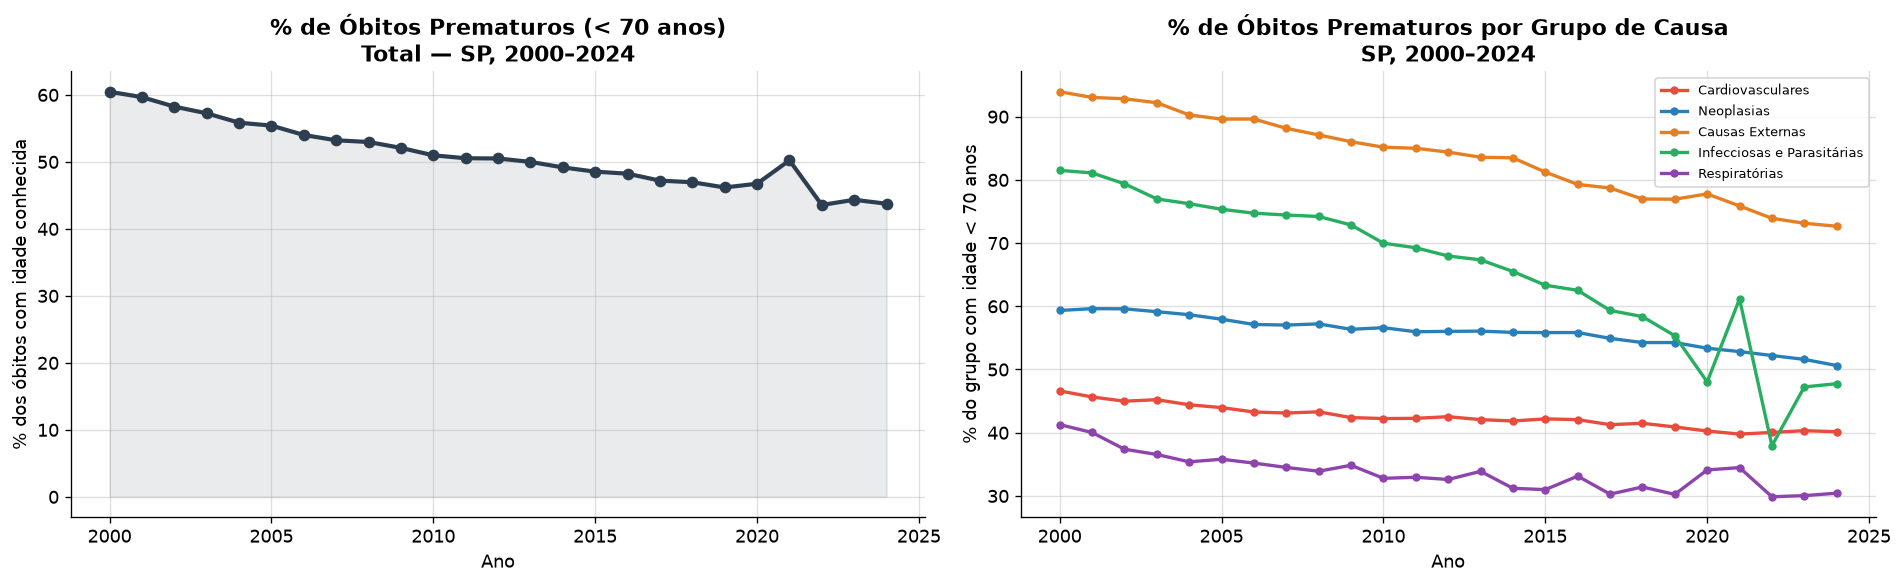


                                           2000     2024     Δ pp
----------------------------------------------------------
TOTAL                                      60.5     43.7    -16.7
Cardiovasculares                           46.6     40.1     -6.5
Neoplasias                                 59.3     50.6     -8.7
Causas Externas                            93.9     72.7    -21.3
Infecciosas e Parasitárias                 81.5     47.7    -33.7
Respiratórias                              41.3     30.4    -10.8


In [22]:

# ── Seção 12: Mortalidade Prematura ───────────────────────────────────────────
LIMIAR_PREMATURO = 70

df_prem = df[df['IDADE'].between(0, 120)].copy()
df_prem['PREMATURO'] = df_prem['IDADE'] < LIMIAR_PREMATURO

# Taxa global de prematuridade por ano
prem_ano = (
    df_prem.groupby('ANO')
           .agg(total=('PREMATURO', 'count'), prematuros=('PREMATURO', 'sum'))
           .assign(pct_prem=lambda x: x['prematuros'] / x['total'] * 100)
           .reset_index()
)

# Por grupo de causa (5 principais)
GRUPOS_PREM = ['Cardiovasculares', 'Neoplasias', 'Causas Externas',
               'Infecciosas e Parasitárias', 'Respiratórias']
CORES_PREM  = ['#e74c3c', '#2980b9', '#e67e22', '#27ae60', '#8e44ad']

prem_gc = (
    df_prem[df_prem['GRUPO_CAUSA'].isin(GRUPOS_PREM)]
    .groupby(['ANO', 'GRUPO_CAUSA'])
    .agg(total=('PREMATURO', 'count'), prematuros=('PREMATURO', 'sum'))
    .assign(pct_prem=lambda x: x['prematuros'] / x['total'] * 100)
    .reset_index()
)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Painel 1: tendência global de prematuridade
ax = axes[0]
ax.plot(prem_ano['ANO'], prem_ano['pct_prem'], marker='o', linewidth=2.5,
        color='#2c3e50')
ax.fill_between(prem_ano['ANO'], prem_ano['pct_prem'],
                alpha=0.1, color='#2c3e50')
ax.set_title('% de Óbitos Prematuros (< 70 anos)\nTotal — SP, 2000–2024',
             fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% dos óbitos com idade conhecida')

# Painel 2: por grupo de causa
ax2 = axes[1]
for grupo, cor in zip(GRUPOS_PREM, CORES_PREM):
    s = prem_gc[prem_gc['GRUPO_CAUSA'] == grupo]
    ax2.plot(s['ANO'], s['pct_prem'], marker='o', ms=4,
             linewidth=2, label=grupo, color=cor)
ax2.set_title('% de Óbitos Prematuros por Grupo de Causa\nSP, 2000–2024',
              fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('% do grupo com idade < 70 anos')
ax2.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURAS / 'fig17_mortalidade_prematura.png', bbox_inches='tight')
plt.show()

# ── Tabela resumo: 2000 vs 2024 ───────────────────────────────────────────────
print(f'\n{"":38} {"2000":>8} {"2024":>8} {"Δ pp":>8}')
print('-' * 58)

linha_total = prem_ano.set_index('ANO')['pct_prem']
print(f'{"TOTAL":<38} {linha_total[2000]:>8.1f} {linha_total[2024]:>8.1f}'
      f' {linha_total[2024]-linha_total[2000]:>+8.1f}')

gc_pivot = prem_gc.pivot(index='ANO', columns='GRUPO_CAUSA', values='pct_prem')
for grupo in GRUPOS_PREM:
    if grupo in gc_pivot.columns:
        v0, v24 = gc_pivot.loc[2000, grupo], gc_pivot.loc[2024, grupo]
        print(f'{grupo:<38} {v0:>8.1f} {v24:>8.1f} {v24-v0:>+8.1f}')


---
## 13. Modelagem de Séries Temporais
**13.1** Decomposição STL da série mensal (tendência + sazonalidade + resíduo).  
**13.2** ARIMA(1,1,1) sobre a série anual — projeção 2025–2030.

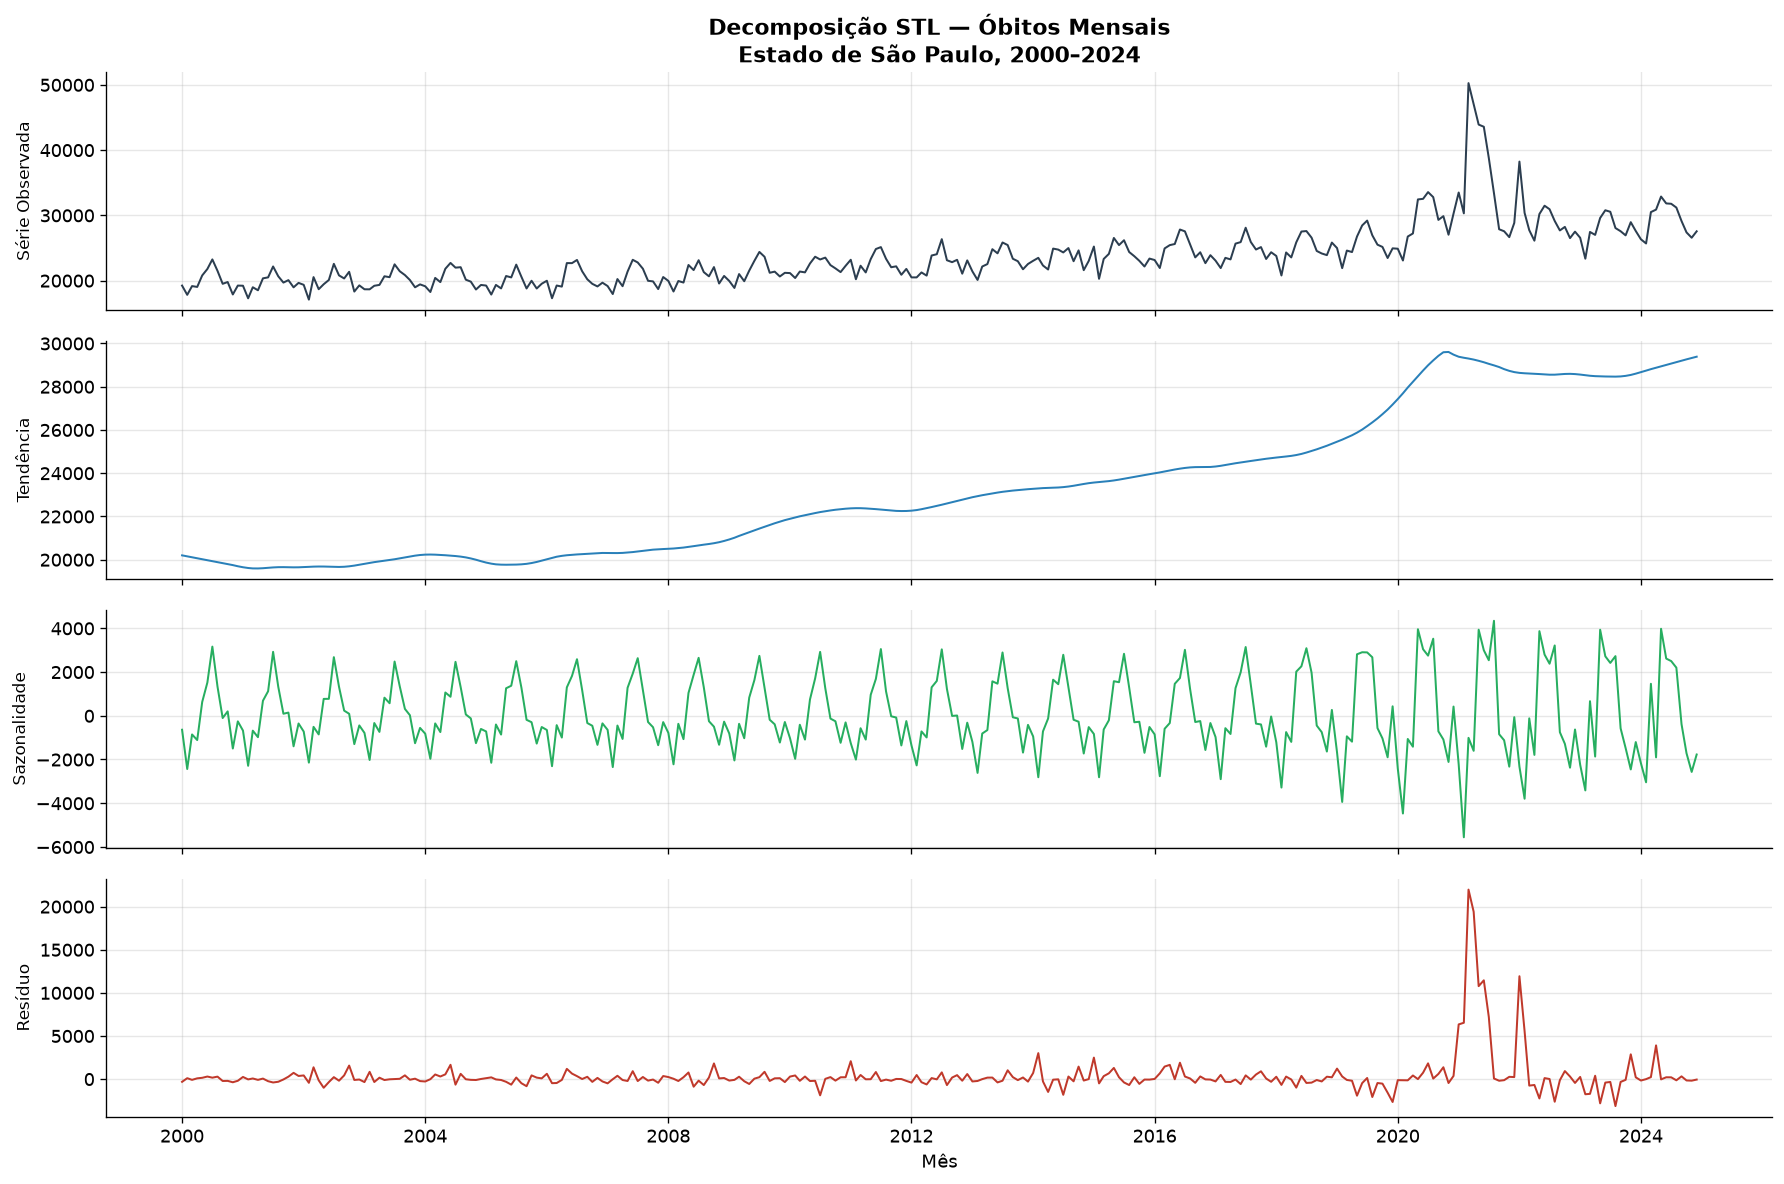

Variância explicada pela tendência + sazonalidade: 76.0%
Variância residual: 24.0%

ARIMA(1,1,1) — AIC=561.7  BIC=565.2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4442      4.883      0.091      0.928      -9.126      10.015
ma.L1         -0.4865      4.786     -0.102      0.919      -9.866       8.893
sigma2      7.811e+08    6.2e-08   1.26e+16      0.000    7.81e+08    7.81e+08


ValueError: No supported index is available.

In [26]:

# ── Seção 13: Séries Temporais ────────────────────────────────────────────────
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# ── 13.1 STL — série mensal 2000–2024 ─────────────────────────────────────────
mensal_stl = (
    df.groupby('ANO_MES').size()
      .reset_index(name='obitos')
      .sort_values('ANO_MES')
)
mensal_stl.index = pd.PeriodIndex(mensal_stl['ANO_MES'], freq='M').to_timestamp()
serie_mensal = mensal_stl['obitos'].astype(float)

stl = STL(serie_mensal, period=12, robust=True)
res = stl.fit()

fig_stl, axes_stl = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
for ax, componente, titulo, cor in zip(
    axes_stl,
    [serie_mensal, res.trend, res.seasonal, res.resid],
    ['Série Observada', 'Tendência', 'Sazonalidade', 'Resíduo'],
    ['#2c3e50', '#2980b9', '#27ae60', '#c0392b']
):
    ax.plot(serie_mensal.index, componente, color=cor, linewidth=1.2)
    ax.set_ylabel(titulo, fontsize=10)
    ax.grid(True, alpha=0.3)

axes_stl[0].set_title('Decomposição STL — Óbitos Mensais\nEstado de São Paulo, 2000–2024',
                       fontsize=13, fontweight='bold')
axes_stl[-1].set_xlabel('Mês')
fig_stl.tight_layout()
fig_stl.savefig(FIGURAS / 'fig18_stl_decomposicao.png', bbox_inches='tight')
plt.show()

# Variância do resíduo como % da variância total (qualidade da decomposição)
var_resid = res.resid.var() / serie_mensal.var() * 100
print(f'Variância explicada pela tendência + sazonalidade: {100 - var_resid:.1f}%')
print(f'Variância residual: {var_resid:.1f}%')

# ── 13.2 ARIMA(1,1,1) — série anual 2000–2024 ─────────────────────────────────
serie_anual = (
    df.groupby('ANO').size()
      .loc[2000:2024]
      .astype(float)
)

modelo = ARIMA(serie_anual, order=(1, 1, 1))
fit    = modelo.fit()
print(f'\nARIMA(1,1,1) — AIC={fit.aic:.1f}  BIC={fit.bic:.1f}')
print(fit.summary().tables[1])

# Projeção 2025–2030
forecast = fit.get_forecast(steps=6)
f_mean   = forecast.predicted_mean
f_ci     = forecast.conf_int(alpha=0.10)   # IC 90%
f_anos   = np.arange(2025, 2031)

fig_ar, ax = plt.subplots(figsize=(13, 5))

# Série histórica (excluindo 2020-2021 visualmente marcados)
ax.plot(serie_anual.index, serie_anual.values, marker='o', linewidth=2,
        color='#2c3e50', label='Observado')
ax.axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID-19')

# Projeção
ax.plot(f_anos, f_mean.values, marker='s', linewidth=2,
        color='#e74c3c', linestyle='--', label='Projeção ARIMA(1,1,1)')
ax.fill_between(f_anos, f_ci.iloc[:, 0], f_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='IC 90%')

ax.set_title('Projeção de Óbitos Totais — Estado de São Paulo\nARIMA(1,1,1), projeção 2025–2030',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de óbitos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}k'))
ax.legend(fontsize=9)
plt.tight_layout()
fig_ar.savefig(FIGURAS / 'fig19_arima_projecao.png', bbox_inches='tight')
plt.show()

print('\nProjeção ARIMA 2025–2030:')
proj_tab = pd.DataFrame({
    'Ano': f_anos,
    'Projeção': f_mean.values.astype(int),
    'IC_inf': f_ci.iloc[:, 0].astype(int),
    'IC_sup': f_ci.iloc[:, 1].astype(int),
})
print(proj_tab.to_string(index=False))


---
## 14. Clustering de Municípios por Perfil Epidemiológico
K-means sobre as proporções de grupos de causa por município (2000–2024).  
Municípios com ≥ 500 óbitos no período são incluídos (~80–90% do total de óbitos do estado).  
PCA 2D para visualização dos clusters.

Municípios com ≥ 500 óbitos: 603
Óbitos cobertos: 7,079,384 (99.8% do total)


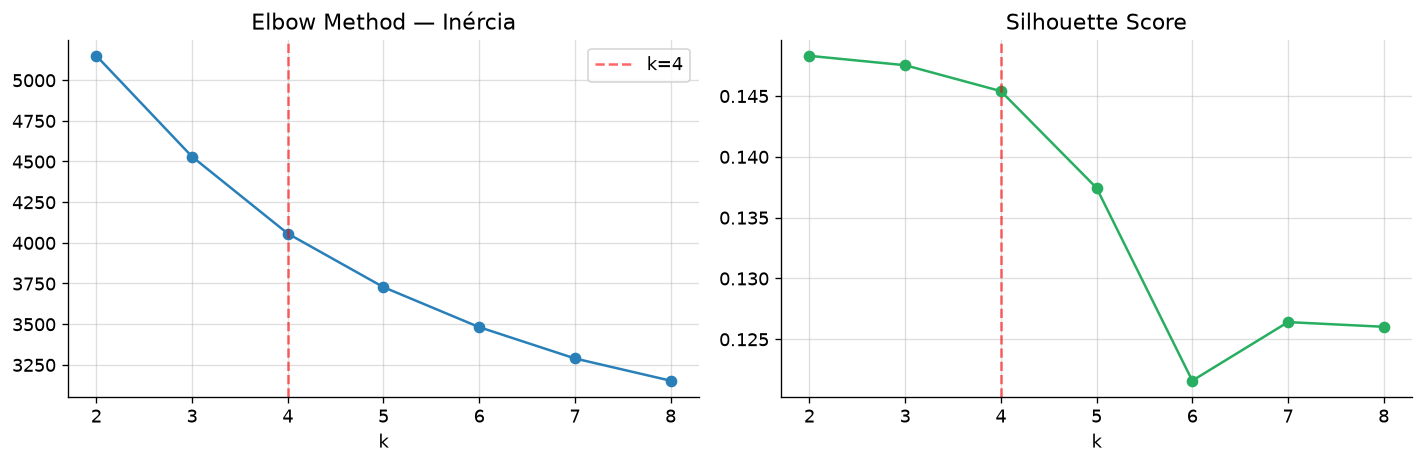

Silhouette para k=4: 0.145


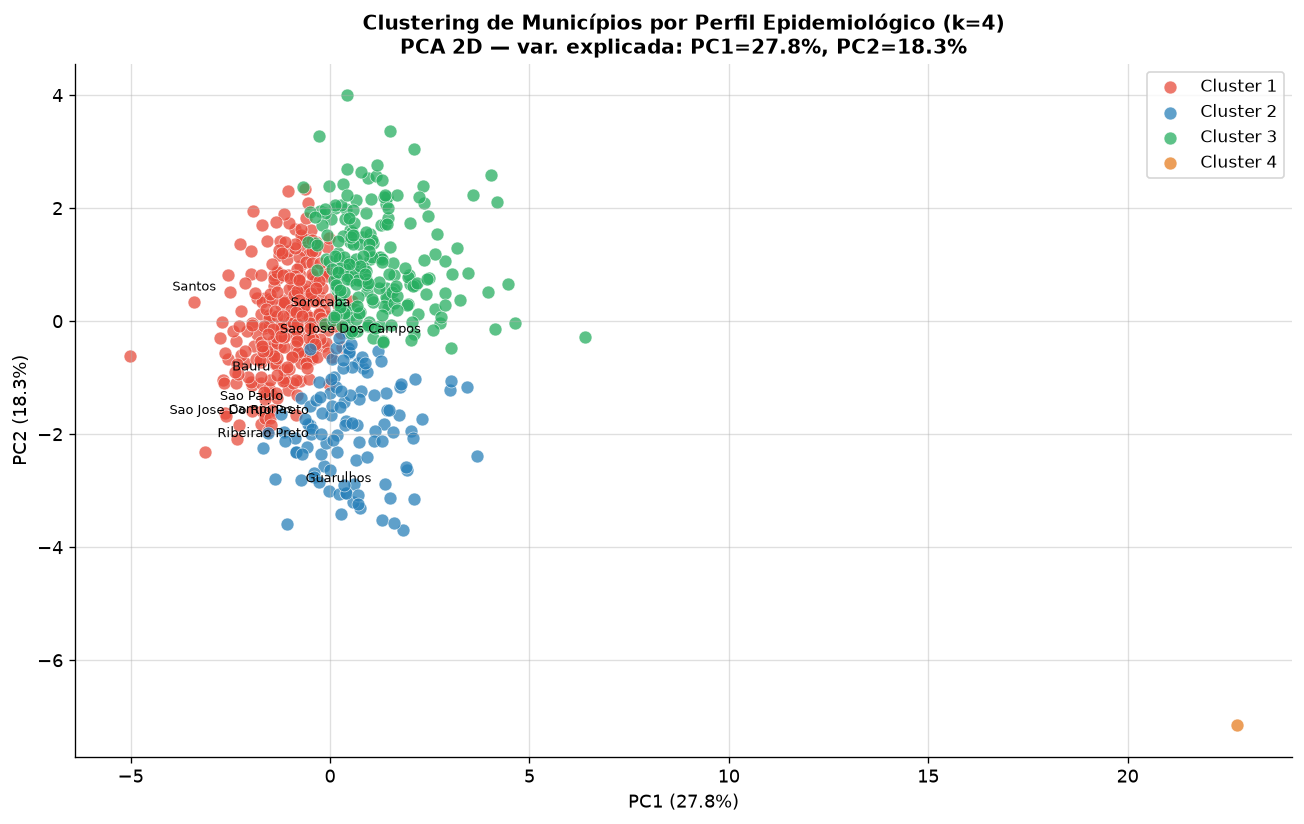


Perfil médio por cluster:
CLUSTER                           0        1       2        3
Cardiovasculares               28.4     29.6    25.7     10.0
Neoplasias                     16.6     16.1    14.7      1.5
Causas Externas                 7.6     10.3     8.6     56.4
Infecciosas e Parasitárias      5.9      6.8     5.8      3.9
Respiratórias                  13.4     11.6    11.4      6.5
Endócrinas e Metabólicas        5.3      5.1     6.0      1.1
Digestivas                      5.6      6.0     5.2      4.5
Causas Mal Definidas            7.6      4.7    13.1     13.1
IDADE_MEDIANA                  72.5     67.4    69.7     45.1
PCT_MASCULINO                  56.5     58.4    58.4     89.0
total                       14888.8  14496.2  5806.6  22540.0
n_municipios                  284.0    113.0   205.0      1.0


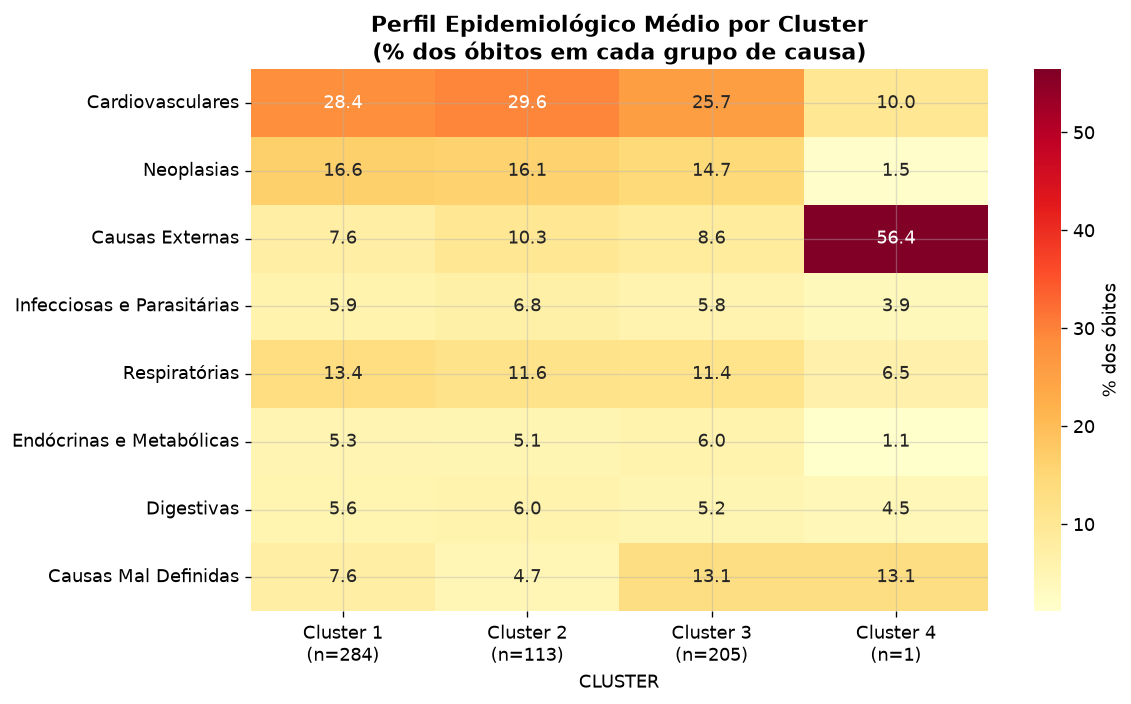


municipos_clusters.csv salvo.


In [27]:

# ── Seção 14: Clustering de Municípios ────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

N_CLUSTERS = 4
MIN_OBITOS = 500
GRUPOS_CLUST = ['Cardiovasculares', 'Neoplasias', 'Causas Externas',
                'Infecciosas e Parasitárias', 'Respiratórias',
                'Endócrinas e Metabólicas', 'Digestivas', 'Causas Mal Definidas']

# ── Matrix município × proporção por grupo de causa ───────────────────────────
mun_gc = (
    df[df['GRUPO_CAUSA'].isin(GRUPOS_CLUST)]
    .groupby(['MUNNOMEX', 'GRUPO_CAUSA'])
    .size()
    .reset_index(name='n')
)
total_mun = df.groupby('MUNNOMEX').size().reset_index(name='total')
mun_gc = mun_gc.merge(total_mun, on='MUNNOMEX')
mun_gc['prop'] = mun_gc['n'] / mun_gc['total'] * 100

feat = (
    mun_gc.pivot(index='MUNNOMEX', columns='GRUPO_CAUSA', values='prop')
          .fillna(0)
)
# Adiciona indicadores demográficos
feat['IDADE_MEDIANA'] = (
    df[df['IDADE'].between(0, 120)]
    .groupby('MUNNOMEX')['IDADE'].median()
)
feat['PCT_MASCULINO'] = (
    df[df['SEXO_NOME'].isin(['Masculino', 'Feminino'])]
    .groupby('MUNNOMEX')['SEXO_NOME']
    .apply(lambda x: (x == 'Masculino').mean() * 100)
)
feat = feat.join(total_mun.set_index('MUNNOMEX'))
feat = feat[feat['total'] >= MIN_OBITOS].dropna()

print(f'Municípios com ≥ {MIN_OBITOS} óbitos: {len(feat)}')
print(f'Óbitos cobertos: {feat["total"].sum():,} ({feat["total"].sum()/len(df)*100:.1f}% do total)')

X_cols = [c for c in feat.columns if c != 'total']
X = feat[X_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Escolha de k: elbow + silhouette ─────────────────────────────────────────
inercias = []
silhouettes = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig_k, axes_k = plt.subplots(1, 2, figsize=(12, 4))
axes_k[0].plot(list(K_range), inercias, marker='o', color='#2980b9')
axes_k[0].axvline(N_CLUSTERS, color='red', linestyle='--', alpha=0.6, label=f'k={N_CLUSTERS}')
axes_k[0].set_title('Elbow Method — Inércia'); axes_k[0].set_xlabel('k'); axes_k[0].legend()
axes_k[1].plot(list(K_range), silhouettes, marker='o', color='#27ae60')
axes_k[1].axvline(N_CLUSTERS, color='red', linestyle='--', alpha=0.6)
axes_k[1].set_title('Silhouette Score'); axes_k[1].set_xlabel('k')
plt.tight_layout()
plt.show()
print(f'Silhouette para k={N_CLUSTERS}: {silhouettes[N_CLUSTERS-2]:.3f}')

# ── K-means final ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=30)
feat['CLUSTER'] = km_final.fit_predict(X_scaled)

# ── PCA 2D ────────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
feat['PC1'], feat['PC2'] = X_pca[:, 0], X_pca[:, 1]

CORES_CLUST = ['#e74c3c', '#2980b9', '#27ae60', '#e67e22']
fig_pca, ax_pca = plt.subplots(figsize=(11, 7))
for cl in range(N_CLUSTERS):
    mask = feat['CLUSTER'] == cl
    ax_pca.scatter(feat.loc[mask, 'PC1'], feat.loc[mask, 'PC2'],
                   c=CORES_CLUST[cl], s=60, alpha=0.75, label=f'Cluster {cl+1}',
                   edgecolors='white', linewidths=0.4)

# Rotula municípios grandes
ROTULAR = ['SAO PAULO', 'CAMPINAS', 'GUARULHOS', 'SANTOS', 'RIBEIRAO PRETO',
           'SAO JOSE DOS CAMPOS', 'SOROCABA', 'BAURU', 'SAO JOSE DO RIO PRETO']
for mun in ROTULAR:
    if mun in feat.index:
        ax_pca.annotate(mun.title(), (feat.loc[mun, 'PC1'], feat.loc[mun, 'PC2']),
                        fontsize=7.5, ha='center', va='bottom',
                        xytext=(0, 5), textcoords='offset points')

ax_pca.set_title(f'Clustering de Municípios por Perfil Epidemiológico (k={N_CLUSTERS})\n'
                 f'PCA 2D — var. explicada: PC1={pca.explained_variance_ratio_[0]*100:.1f}%,'
                 f' PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
                 fontsize=12, fontweight='bold')
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax_pca.legend(fontsize=10)
plt.tight_layout()
fig_pca.savefig(FIGURAS / 'fig20_clustering_municipios.png', bbox_inches='tight')
plt.show()

# ── Perfil médio de cada cluster ──────────────────────────────────────────────
perfil = (
    feat.groupby('CLUSTER')[GRUPOS_CLUST + ['IDADE_MEDIANA', 'PCT_MASCULINO', 'total']]
        .mean()
        .round(1)
)
perfil['n_municipios'] = feat.groupby('CLUSTER').size()
print('\nPerfil médio por cluster:')
print(perfil.T.to_string())

# ── Heatmap do perfil ─────────────────────────────────────────────────────────
fig_heat, ax_h = plt.subplots(figsize=(10, 6))
sns.heatmap(
    perfil[GRUPOS_CLUST].T,
    annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=[f'Cluster {i+1}\n(n={perfil.loc[i,"n_municipios"]:.0f})' for i in range(N_CLUSTERS)],
    ax=ax_h, cbar_kws={'label': '% dos óbitos'}
)
ax_h.set_title('Perfil Epidemiológico Médio por Cluster\n(% dos óbitos em cada grupo de causa)',
               fontweight='bold')
plt.tight_layout()
fig_heat.savefig(FIGURAS / 'fig21_perfil_clusters.png', bbox_inches='tight')
plt.show()

# Exporta tabela de municípios com cluster
feat[['CLUSTER', 'total'] + GRUPOS_CLUST[:4]].to_csv(
    'variavel/municipios_clusters.csv', sep=';', decimal=','
)
print('\nmunicipos_clusters.csv salvo.')


---
## Próximos passos

- [x] ~~Baixar dados populacionais IBGE e executar seção 2 (taxa por 100k)~~
- [x] ~~Análise de desigualdade racial com teste estatístico (Kruskal-Wallis)~~
- [x] ~~Mortalidade prematura (< 70 anos) por grupo de causa (Seção 12)~~
- [x] ~~Modelagem de séries temporais: STL + ARIMA(1,1,1) (Seção 13)~~
- [x] ~~Clustering de municípios por perfil epidemiológico (Seção 14)~~
- [ ] Integrar figuras ao texto da monografia (seção Resultados)
- [ ] Revisão final com orientador: interpretar clusters + projeção ARIMA